# Modelo aplicado TTAP - Comparación de métodos para paper (Exacto y Heurístico):
#### Eduardo Carrasco Vidal - 22 junio 2026 - Estudiante Doctorado en Ingeniería de Sistemas Complejos

In [1]:
import numpy as np
import pandas as pd
import scipy
import matplotlib
import pulp
import sys
import os
import platform

print("Computational Environment")
print("Python:", sys.version)
print("Platform:", platform.platform())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("SciPy:", scipy.__version__)
print("Matplotlib:", matplotlib.__version__)
print("PuLP:", pulp.__version__)


Computational Environment
Python: 3.11.3 (main, Apr 19 2023, 18:49:55) [Clang 14.0.6 ]
Platform: macOS-26.5.2-arm64-arm-64bit
NumPy: 1.26.4
Pandas: 3.0.3
SciPy: 1.10.1
Matplotlib: 3.7.1
PuLP: 2.8.0


In [2]:
# Objetivo:
# Comparar una heurística greedy y un modelo exacto sobre la misma instancia TTAP.

import math
import time
from collections import deque, defaultdict
from typing import List
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from scipy.optimize import milp, LinearConstraint, Bounds
from scipy.sparse import coo_matrix

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

### 1. Definición del problema:

In [3]:
# El TTAP consiste en asignar helicópteros heterogéneos a tareas
# distribuidas espacialmente, maximizando el beneficio operacional
# acumulado bajo restricciones de:
#
# - compatibilidad helicóptero-tarea;
# - capacidades de carga, atención médica y traslado de personal;
# - tiempo de vuelo;
# - tiempo de servicio;
# - retorno a base y recuperación;
# - horizonte temporal;
# - ejecución única de cada tarea.
#
# En esta instancia estática:
# todas las tareas están disponibles desde t = 0.
#
# Beneficio temporal:
#
# b_i(t) = S_i(t) / |I|
#
# donde:
#
# S_i(t) = 1, si t <= t_opt_i
# S_i(t) = 0, si t >= t_ineff_i
# S_i(t) = 1 / (1 + exp(alpha * (t - t_eff_i))), en otro caso.
#
# ============================================================

SERVICE_TIME = 6.0
RECOVERY_TIME = 2.0
TMAX = 200.0
ALPHA = 0.1

USE_PRIORITY_WEIGHTS = True

PRIORITY_WEIGHTS = {
    "medical": 2.0,
    "personnel": 1.5,
    "cargo": 1.0,
}

EFFECTIVE_SATISFACTION_THRESHOLD = 0.5

# Discretización temporal del modelo exacto
TIME_UNIT = 1.0

# Criterio para no seleccionar tareas sin beneficio.
# Si una tarea tiene beneficio 0, no se considera útil para el greedy.
ZERO_BENEFIT_TOL = 0.0

# Escala común para gráficos de beneficio acumulado
BENEFIT_Y_MIN = 0.0
BENEFIT_Y_MAX = 0.70
BENEFIT_Y_STEP = 0.05

# Carpeta para guardar figuras
FIGURES_DIR = "figures_ttap_GPS"
os.makedirs(FIGURES_DIR, exist_ok=True)

def save_current_figure_dual(save_name, dpi=600):
    """
    Guarda la figura actual en formato PNG y PDF.

    Ejemplo:
        save_current_figure_dual("gantt_greedy_ttap")
    """

    base_name, ext = os.path.splitext(save_name)

    if ext.lower() in [".png", ".pdf"]:
        save_name = base_name

    png_path = os.path.join(FIGURES_DIR, f"{save_name}.png")
    pdf_path = os.path.join(FIGURES_DIR, f"{save_name}.pdf")

    plt.savefig(
        png_path,
        dpi=dpi,
        bbox_inches="tight"
    )

    plt.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    print(f"Figure saved at: {png_path}")
    print(f"Figure saved at: {pdf_path}")

### 2. Datos del escenario:

In [4]:
# ============================================================
# Configuración del escenario
# ============================================================

N_DEMAND_NODES = 7      # opciones recomendadas: 4 o 7
N_HELICOPTERS = 6       # opciones recomendadas: 4 o 6
N_TASKS = 30            # opciones: 20 o 30

SCENARIO_NAME = f"GPS_{N_DEMAND_NODES}areas_{N_HELICOPTERS}helos_{N_TASKS}tasks"

# Carpeta para guardar figuras del escenario
FIGURES_DIR = os.path.join("figures_ttap_GPS", SCENARIO_NAME)
os.makedirs(FIGURES_DIR, exist_ok=True)

# ============================================================
# Nodos GPS
# ============================================================

GPS_NODES_FULL = {
    "Base": (-36.69111351421891, -73.0478599920742),
    "A": (-36.70062541801277, -73.12141380985622), # Cancha Colegio Arturo Prat
    "B": (-36.738871104828384, -73.1102591903089), # Estacionamiento Hospital Higueras
    "C": (-36.75513285670206, -73.10765044444817), # Estadio Cap Huachipato
    "D": (-36.78339332263817, -73.09259088926588), # Club Hípico
    "E": (-36.784954466865976, -73.05085478019805), # Colegio Kingston College
    "F": (-36.83173804040988, -73.06322287960043), # Parque Bicentenario
    "G": (-36.81499794336835, -73.02359653839595), # Estadio Ester Roa
}

DEMAND_NODE_ORDER = ["A", "B", "C", "D", "E", "F", "G"]


def build_active_nodes(n_demand_nodes):
    if n_demand_nodes < 1 or n_demand_nodes > len(DEMAND_NODE_ORDER):
        raise ValueError(
            f"n_demand_nodes debe estar entre 1 y {len(DEMAND_NODE_ORDER)}"
        )

    active_names = ["Base"] + DEMAND_NODE_ORDER[:n_demand_nodes]

    active_nodes = {
        name: GPS_NODES_FULL[name]
        for name in active_names
    }

    return active_names, active_nodes


ACTIVE_NODE_NAMES, nodes = build_active_nodes(N_DEMAND_NODES)

# ============================================================
# Tareas base
# ============================================================

BASE_TASK_ROWS = [
    # task_id, visual_required, load, med, pers, t_opt, t_eff, t_ineff
    (1,  True,  200, 2, 1, 20, 40, 60),
    (2,  False, 300, 1, 2, 15, 30, 50),
    (3,  True,  100, 3, 0, 10, 25, 40),
    (4,  False, 200, 0, 3, 30, 50, 70),
    (5,  True,  150, 1, 1, 25, 45, 60),
    (6,  True,  100, 3, 0, 10, 25, 120),
    (7,  False, 400, 0, 3, 30, 50, 90),
    (8,  True,  150, 1, 1, 25, 45, 100),
    (9,  True,  200, 2, 1, 20, 40, 60),
    (10, False, 300, 1, 2, 15, 30, 50),
    (11, True,  100, 3, 0, 10, 25, 40),
    (12, False, 200, 0, 3, 30, 50, 70),
    (13, True,  150, 1, 1, 25, 45, 60),
    (14, True,  100, 3, 0, 10, 25, 120),
    (15, False, 400, 0, 3, 30, 50, 90),
    (16, True,  150, 1, 1, 25, 45, 100),
    (17, True,  150, 1, 1, 25, 45, 60),
    (18, True,  100, 3, 0, 10, 25, 120),
    (19, False, 400, 0, 3, 30, 50, 90),
    (20, True,  150, 1, 1, 25, 45, 100),
]

# Asignación espacial original de las 20 tareas base
BASE_TASK_TO_NODE = {}

for i in [1, 2, 9, 10]:
    BASE_TASK_TO_NODE[i] = "A"

for i in [3, 8, 7, 11, 12, 13, 14]:
    BASE_TASK_TO_NODE[i] = "B"

for i in [5, 6, 15, 16]:
    BASE_TASK_TO_NODE[i] = "C"

for i in [4, 17, 18, 19, 20]:
    BASE_TASK_TO_NODE[i] = "D"


def build_task_rows(n_tasks):
    """
    Construye el conjunto de tareas.
    - Si n_tasks = 20, usa exactamente las 20 tareas base.
    - Si n_tasks = 30, mantiene intactas las 20 tareas base
      y agrega 10 tareas nuevas replicando los perfiles de T1-T10.
    """

    if n_tasks not in [20, 30]:
        raise ValueError("Por ahora N_TASKS debe ser 20 o 30")

    rows = list(BASE_TASK_ROWS)

    if n_tasks == 30:
        additional_profiles = BASE_TASK_ROWS[:10]

        for new_id, base_row in zip(range(21, 31), additional_profiles):
            _, visual, load, med, pers, t_opt, t_eff, t_ineff = base_row

            rows.append(
                (
                    new_id,
                    visual,
                    load,
                    med,
                    pers,
                    t_opt,
                    t_eff,
                    t_ineff,
                )
            )

    return rows


def build_tasks(task_rows):
    return {
        row[0]: {
            "visual": row[1],
            "load": row[2],
            "med": row[3],
            "pers": row[4],
            "t_opt": row[5],
            "t_eff": row[6],
            "t_ineff": row[7],
        }
        for row in task_rows
    }


def build_task_to_node(tasks, active_node_names):
    """
    Mantiene intacta la asignación original de las tareas 1-20.
    Si existen tareas adicionales, se asignan preferentemente
    a los nodos nuevos E, F y G.
    """

    demand_nodes = [
        name for name in active_node_names
        if name != "Base"
    ]

    task_ids = sorted(tasks.keys())
    task_to_node = {}

    # ========================================================
    # 1. Mantener asignación original para tareas 1-20
    # ========================================================

    for task_id in task_ids:
        if task_id in BASE_TASK_TO_NODE:
            node_name = BASE_TASK_TO_NODE[task_id]

            if node_name not in demand_nodes:
                raise ValueError(
                    f"La tarea base {task_id} está asignada a {node_name}, "
                    f"pero ese nodo no está activo."
                )

            task_to_node[task_id] = node_name

    # ========================================================
    # 2. Asignar tareas adicionales, si existen
    # ========================================================

    additional_task_ids = [
        task_id for task_id in task_ids
        if task_id not in BASE_TASK_TO_NODE
    ]

    # Si existen E, F y G activos, las tareas nuevas se asignan ahí.
    new_task_nodes = [
        node_name for node_name in ["E", "F", "G"]
        if node_name in demand_nodes
    ]

    # Si no están activos E-G, se asignan a los nodos de demanda disponibles.
    if len(new_task_nodes) == 0:
        new_task_nodes = demand_nodes

    for idx, task_id in enumerate(additional_task_ids):
        node_name = new_task_nodes[idx % len(new_task_nodes)]
        task_to_node[task_id] = node_name

    # Control de consistencia
    missing_tasks = sorted(set(task_ids) - set(task_to_node.keys()))

    if len(missing_tasks) > 0:
        raise ValueError(
            f"Hay tareas sin nodo asignado: {missing_tasks}"
        )

    return task_to_node

task_rows = build_task_rows(N_TASKS)
tasks = build_tasks(task_rows)

def classify_task_priority(task):
    if task["med"] > 0:
        return "medical"

    if task["pers"] > 0:
        return "personnel"

    if task["load"] > 0:
        return "cargo"

    raise ValueError(
        "La tarea no tiene una necesidad operacional definida."
    )


for task in tasks.values():
    priority_class = classify_task_priority(task)

    task["priority_class"] = priority_class
    task["weight"] = (
        PRIORITY_WEIGHTS[priority_class]
        if USE_PRIORITY_WEIGHTS
        else 1.0
    )


TOTAL_TASK_WEIGHT = sum(
    task["weight"]
    for task in tasks.values()
)


task_to_node = build_task_to_node(
    tasks,
    ACTIVE_NODE_NAMES
)

print("Total task weight:", TOTAL_TASK_WEIGHT)

# ============================================================
# Helicópteros
# ============================================================

FLEET_ROWS = [
    ("H1", "H125_light",        True,  300, 1, 2, 190),
    ("H2", "H125_light",        False, 300, 1, 2, 190),

    ("H3", "AS365_Dauphin",     True,  500, 2, 4, 210),
    ("H4", "AS365_Dauphin",     False, 500, 2, 4, 210),

    ("H5", "H215M_Cougar",      True,  900, 3, 8, 200),
    ("H6", "H215M_Cougar",      False, 900, 3, 8, 200),
]


def build_helicopters(n_helicopters):
    if n_helicopters < 1 or n_helicopters > len(FLEET_ROWS):
        raise ValueError(
            f"n_helicopters debe estar entre 1 y {len(FLEET_ROWS)}"
        )

    selected_rows = FLEET_ROWS[:n_helicopters]

    return {
        h: {
            "model": model,
            "visual": visual,
            "load": load,
            "med": med,
            "pers": pers,
            "speed": speed,
        }
        for h, model, visual, load, med, pers, speed in selected_rows
    }


helicopters = build_helicopters(N_HELICOPTERS)

# ============================================================
# Control de configuración
# ============================================================

print("=" * 70)
print("SCENARIO CONFIGURATION")
print("=" * 70)

print(f"Scenario name     : {SCENARIO_NAME}")
print(f"Demand nodes      : {N_DEMAND_NODES}")
print(f"Active nodes      : {ACTIVE_NODE_NAMES}")
print(f"Helicopters       : {N_HELICOPTERS}")
print(f"Tasks             : {N_TASKS}")
print(f"Figures directory : {FIGURES_DIR}")

print("\nTasks per node:")
task_distribution = (
    pd.Series(task_to_node)
    .value_counts()
    .sort_index()
)

display(task_distribution.to_frame("Number of tasks"))

print("\nTask-to-node assignment:")
display(
    pd.DataFrame({
        "Task ID": list(task_to_node.keys()),
        "Node": list(task_to_node.values())
    }).sort_values("Task ID")
)

print("\nFleet:")
display(pd.DataFrame(helicopters).T)

Total task weight: 56.5
SCENARIO CONFIGURATION
Scenario name     : GPS_7areas_6helos_30tasks
Demand nodes      : 7
Active nodes      : ['Base', 'A', 'B', 'C', 'D', 'E', 'F', 'G']
Helicopters       : 6
Tasks             : 30
Figures directory : figures_ttap_GPS/GPS_7areas_6helos_30tasks

Tasks per node:


,Number of tasks
A,4
B,7
C,4
D,5
E,4
F,3
G,3



Task-to-node assignment:


,Task ID,Node
0,1,A
1,2,A
2,3,B
3,4,D
4,5,C
5,6,C
6,7,B
7,8,B
8,9,A
9,10,A



Fleet:


,model,visual,load,med,pers,speed
H1,H125_light,True,300,1,2,190
H2,H125_light,False,300,1,2,190
H3,AS365_Dauphin,True,500,2,4,210
H4,AS365_Dauphin,False,500,2,4,210
H5,H215M_Cougar,True,900,3,8,200
H6,H215M_Cougar,False,900,3,8,200


### 3. Funciones comunes:

In [5]:
def haversine_distance_km(node_a, node_b):
    """
    Calcula la distancia geodésica aproximada entre dos nodos GPS
    usando la fórmula de Haversine.

    Las coordenadas deben estar en formato:
    (latitud, longitud)

    Retorna distancia en kilómetros.
    """

    lat1, lon1 = nodes[node_a]
    lat2, lon2 = nodes[node_b]

    radius_earth_km = 6371.0088

    lat1_rad = math.radians(lat1)
    lon1_rad = math.radians(lon1)
    lat2_rad = math.radians(lat2)
    lon2_rad = math.radians(lon2)

    delta_lat = lat2_rad - lat1_rad
    delta_lon = lon2_rad - lon1_rad

    a = (
        math.sin(delta_lat / 2.0) ** 2
        + math.cos(lat1_rad)
        * math.cos(lat2_rad)
        * math.sin(delta_lon / 2.0) ** 2
    )

    c = 2.0 * math.asin(math.sqrt(a))

    return radius_earth_km * c
    

def travel_time_minutes(h, node_a, node_b):
    if node_a == node_b:
        return 0.0

    distance_km = haversine_distance_km(node_a, node_b)
    speed_kmh = helicopters[h]["speed"]

    return 60.0 * distance_km / speed_kmh


def logistic_core(t, t_eff):
    return 1.0 / (
        1.0 + math.exp(ALPHA * (t - t_eff))
    )


def satisfaction(t, task):
    t_opt = task["t_opt"]
    t_eff = task["t_eff"]
    t_ineff = task["t_ineff"]

    if not (t_opt < t_eff < t_ineff):
        raise ValueError(
            "Los umbrales deben cumplir "
            "t_opt < t_eff < t_ineff."
        )

    if t <= t_opt:
        return 1.0

    if t >= t_ineff:
        return 0.0

    logistic_t = logistic_core(t, t_eff)
    logistic_eff = 0.5

    if t <= t_eff:
        logistic_opt = logistic_core(
            t_opt,
            t_eff
        )

        value = (
            0.5
            + 0.5
            * (logistic_t - logistic_eff)
            / (logistic_opt - logistic_eff)
        )
    else:
        logistic_ineff = logistic_core(
            t_ineff,
            t_eff
        )

        value = (
            0.5
            * (logistic_t - logistic_ineff)
            / (logistic_eff - logistic_ineff)
        )

    return max(0.0, min(1.0, value))


def task_benefit(task_id, finish_time):
    task = tasks[task_id]

    return (
        task["weight"]
        * satisfaction(finish_time, task)
        / TOTAL_TASK_WEIGHT
    )

def ceil_steps(minutes, time_unit):
    return int(math.ceil((minutes - 1e-9) / time_unit))

def time_from_step(k, time_unit):
    return k * time_unit

def can_execute_task_by_resources(h, task_id, load, med, pers):
    helo = helicopters[h]
    task = tasks[task_id]

    if task["visual"] and not helo["visual"]:
        return False

    if load < task["load"]:
        return False

    if med < task["med"]:
        return False

    if pers < task["pers"]:
        return False

    return True


def helo_to_str(h):
    if isinstance(h, str):
        h = h.strip()
        if h.startswith("H"):
            return h
        return f"H{h}"
    return f"H{int(h)}"


def helo_to_int(h):
    if isinstance(h, str):
        h = h.strip()
        if h.startswith("H"):
            return int(h.replace("H", ""))
        return int(h)
    return int(h)

## Prueba para distancias GPS:

In [6]:
print("GPS nodes activos:")
for node_name, coord in nodes.items():
    print(node_name, coord)

print("\nDistancias desde Base:")
for node_name in nodes:
    if node_name == "Base":
        continue

    d_km = haversine_distance_km("Base", node_name)

    print(
        f"Base → {node_name}: "
        f"{d_km:.3f} km"
    )

GPS nodes activos:
Base (-36.69111351421891, -73.0478599920742)
A (-36.70062541801277, -73.12141380985622)
B (-36.738871104828384, -73.1102591903089)
C (-36.75513285670206, -73.10765044444817)
D (-36.78339332263817, -73.09259088926588)
E (-36.784954466865976, -73.05085478019805)
F (-36.83173804040988, -73.06322287960043)
G (-36.81499794336835, -73.02359653839595)

Distancias desde Base:
Base → A: 6.643 km
Base → B: 7.690 km
Base → C: 8.892 km
Base → D: 11.008 km
Base → E: 10.438 km
Base → F: 15.697 km
Base → G: 13.944 km


In [7]:
import geopandas as gpd

COMUNAS_PATH = "data/limites_comunales/comunas_final.zip"

comunas = gpd.read_file(COMUNAS_PATH)

print(comunas.shape)
print(comunas.crs)
print(comunas.columns)
display(comunas.head())

(346, 12)
EPSG:3857
Index(['objectid', 'shape_leng', 'dis_elec', 'cir_sena', 'cod_comuna', 'codregion', 'st_area_sh', 'st_length_', 'Region', 'Comuna', 'Provincia', 'geometry'], dtype='str')


,objectid,shape_leng,dis_elec,cir_sena,cod_comuna,codregion,st_area_sh,st_length_,Region,Comuna,Provincia,geometry
0,48,170038.624165,16,8,6204,6,9.685774e+08,206184.271675,Región del Libertador Bernardo O'Higgins,Marchigüe,Cardenal Caro,"POLYGON ((-7992818.789 -4056669.319, -7992731...."
1,29,125730.104795,15,8,6102,6,4.157446e+08,151911.576827,Región del Libertador Bernardo O'Higgins,Codegua,Cachapoal,"POLYGON ((-7831651.813 -4022443.109, -7831596...."
2,30,63026.084422,15,8,6103,6,1.448565e+08,76355.326122,Región del Libertador Bernardo O'Higgins,Coinco,Cachapoal,"POLYGON ((-7892616.357 -4060673.364, -7892621...."
3,31,89840.903562,15,8,6104,6,3.256572e+08,108874.623150,Región del Libertador Bernardo O'Higgins,Coltauco,Cachapoal,"POLYGON ((-7906457.717 -4051723.734, -7906266...."
4,78,122626.493264,23,11,9121,9,6.990727e+08,156680.410681,Región de La Araucanía,Cholchol,Cautín,"POLYGON ((-8121756.186 -4645860.295, -8121644...."


In [8]:
import os
import zipfile
from pathlib import Path

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import contextily as ctx

# ============================================================
# Lectura de carta de inundación por tsunami desde KMZ
# ============================================================

TSUNAMI_KMZ_PATH = "data/tsunami/CITSU_Bahias_Concepcion_San Vicente_1ra_Ed2013.kmz"


def read_kmz_as_geodataframe(kmz_path):
    """
    Lee un archivo KMZ que contiene un KML interno y lo devuelve
    como GeoDataFrame.
    """

    kmz_path = Path(kmz_path)

    if not kmz_path.exists():
        raise FileNotFoundError(
            f"No existe el archivo KMZ en:\n{kmz_path}"
        )

    extract_dir = kmz_path.parent / f"{kmz_path.stem}_extracted"
    extract_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(kmz_path, "r") as z:
        z.extractall(extract_dir)

    kml_files = list(extract_dir.rglob("*.kml"))

    if len(kml_files) == 0:
        raise FileNotFoundError(
            f"No se encontró ningún archivo KML dentro de:\n{kmz_path}"
        )

    kml_path = kml_files[0]

    gdf = gpd.read_file(kml_path)

    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=4326)

    return gdf


tsunami_gdf = read_kmz_as_geodataframe(TSUNAMI_KMZ_PATH)

# Limpiar geometrías vacías
tsunami_gdf = tsunami_gdf[
    tsunami_gdf.geometry.notna() & ~tsunami_gdf.geometry.is_empty
].copy()

print("Carta de inundación cargada")
print("Shape:", tsunami_gdf.shape)
print("CRS:", tsunami_gdf.crs)
display(tsunami_gdf[["Name", "geometry"]].head())

Carta de inundación cargada
Shape: (9, 3)
CRS: EPSG:4326


,Name,geometry
0,Profundidad de la inundación: 0 a 1 m,"MULTIPOLYGON Z (((-73.00228 -36.73803 0, -73.0..."
1,Profundidad de la inundación: 1 a 2 m,"MULTIPOLYGON Z (((-73.12398 -36.72364 0, -73.1..."
2,Profundidad de la inundación: 2 a 4 m,"MULTIPOLYGON Z (((-73.13012 -36.72472 0, -73.1..."
3,Profundidad de la inundación: 4 a 6 m,"MULTIPOLYGON Z (((-73.05007 -36.60394 0, -73.0..."
4,Profundidad de la inundación: 4 a 6 m,"MULTIPOLYGON Z (((-73.17466 -36.76438 0, -73.1..."


In [9]:
# ============================================================
# Crear área total de inundación
# ============================================================

# La carta trae varias geometrías por profundidad.
# Para el mapa principal, las unimos en una sola capa roja.
tsunami_area = tsunami_gdf.dissolve()

# Asegurar CRS geográfico de origen
if tsunami_area.crs is None:
    tsunami_area = tsunami_area.set_crs(epsg=4326)

# Reproyectar a Web Mercator para usar con contextily
tsunami_area_3857 = tsunami_area.to_crs(epsg=3857)

CRS comunas: EPSG:3857
Columna usada para comuna: Comuna
Comunas encontradas:


,Comuna
95,Concepción
175,Hualpén
176,Talcahuano


Map saved at: figures_ttap_GPS/GPS_7areas_6helos_30tasks/ttap_gps_area_map_comunas_tsunami_chart.png
Map saved at: figures_ttap_GPS/GPS_7areas_6helos_30tasks/ttap_gps_area_map_comunas_tsunami_chart.pdf


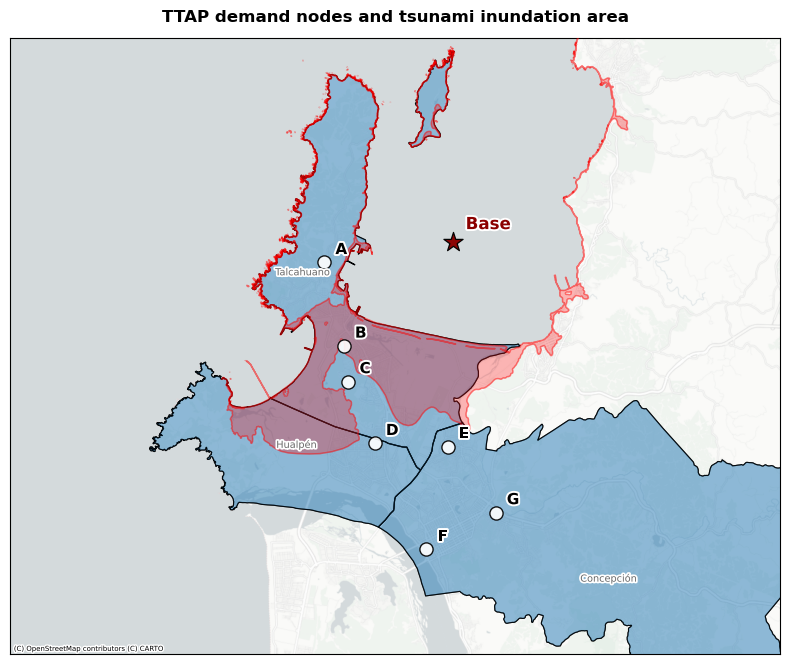

In [10]:
import os
import unicodedata

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from shapely.geometry import Point
import contextily as ctx

# ============================================================
# Parámetros del mapa
# ============================================================

MAP_NAME_TSUNAMI = "ttap_gps_area_map_comunas_tsunami_chart"
MAP_ZOOM_BASE = 12
MAP_ZOOM_LABELS = 11
FIG_SIZE = (8, 8)
PADDING_FACTOR = 0.12

# Ruta al shapefile comprimido
COMUNAS_PATH = "data/limites_comunales/comunas_final.zip"

if "FIGURES_DIR" not in globals():
    FIGURES_DIR = "figures_ttap_GPS"

os.makedirs(FIGURES_DIR, exist_ok=True)

# Comunas a mostrar
AREA_COMUNAS = [
    "Talcahuano",
    "Concepción",
    "Hualpén",
    #"Penco",
    #"Tomé",
    #"San Pedro de la Paz",
    #"Chiguayante",
]

# ============================================================
# Datos GPS de nodos TTAP
# ============================================================

GPS_NODES_FULL = {
    "Base": (-36.69111351421891, -73.0478599920742),
    "A": (-36.70062541801277, -73.12141380985622), # Cancha Colegio Arturo Prat
    "B": (-36.738871104828384, -73.1102591903089), # Estacionamiento Hospital Higueras
    "C": (-36.75513285670206, -73.10765044444817), # Estadio Cap Huachipato
    "D": (-36.78339332263817, -73.09259088926588), # Club Hípico
    "E": (-36.784954466865976, -73.05085478019805), # Colegio Kingston College
    "F": (-36.83173804040988, -73.06322287960043), # Parque Bicentenario
    "G": (-36.81499794336835, -73.02359653839595), # Estadio Ester Roa
}

ACTIVE_NODE_NAMES = ["Base", "A", "B", "C", "D", "E", "F", "G"]

# ============================================================
# Funciones auxiliares
# ============================================================

def normalize_text(value):
    """
    Normaliza texto para comparar nombres con o sin tilde.
    """

    if pd.isna(value):
        return ""

    value = str(value).strip().lower()

    value = "".join(
        c for c in unicodedata.normalize("NFD", value)
        if unicodedata.category(c) != "Mn"
    )

    return value


def read_comunas(path):
    """
    Lee el archivo de comunas.
    Intenta leer directamente el .zip y, si falla, usa zip://.
    """

    if not os.path.exists(path):
        raise FileNotFoundError(
            f"No existe el archivo de comunas en:\n{path}"
        )

    try:
        return gpd.read_file(path)
    except Exception:
        return gpd.read_file(f"zip://{path}")


def find_comuna_column(gdf):
    """
    Detecta la columna que contiene el nombre de la comuna.
    En tu archivo debería ser 'Comuna'.
    """

    candidate_columns = [
        "Comuna",
        "COMUNA",
        "comuna",
        "NOM_COMUNA",
        "nom_comuna",
        "NOMBRE_COM",
        "nombre_com",
        "NOMBRE",
        "nombre",
    ]

    for col in candidate_columns:
        if col in gdf.columns:
            return col

    raise ValueError(
        "No pude detectar la columna de nombre de comuna. "
        f"Columnas disponibles: {list(gdf.columns)}"
    )


# ============================================================
# Cargar límites comunales
# ============================================================

comunas = read_comunas(COMUNAS_PATH)

if comunas.crs is None:
    raise ValueError(
        "El archivo de comunas no tiene CRS definido. "
        "Debes asignar el CRS correcto antes de graficar."
    )

comuna_col = find_comuna_column(comunas)

comunas["_comuna_norm"] = comunas[comuna_col].apply(normalize_text)

area_comunas_norm = [
    normalize_text(name)
    for name in AREA_COMUNAS
]

comunas_area = comunas[
    comunas["_comuna_norm"].isin(area_comunas_norm)
].copy()

if comunas_area.empty:
    raise ValueError(
        "No se encontraron las comunas indicadas. "
        "Revisa AREA_COMUNAS y la columna de nombres."
    )

print("CRS comunas:", comunas.crs)
print("Columna usada para comuna:", comuna_col)
print("Comunas encontradas:")
display(comunas_area[[comuna_col]])

# ============================================================
# Crear GeoDataFrame de nodos TTAP
# ============================================================

node_rows = []

for name in ACTIVE_NODE_NAMES:
    lat, lon = GPS_NODES_FULL[name]

    node_rows.append({
        "name": name,
        "lat": lat,
        "lon": lon,
        "type": "Base" if name == "Base" else "Demand node",
        "geometry": Point(lon, lat),
    })

gdf_nodes = gpd.GeoDataFrame(
    node_rows,
    crs="EPSG:4326"
)

# ============================================================
# Reproyección a Web Mercator
# ============================================================
# Contextily usa mapas base en EPSG:3857.
# Por eso dejamos comunas y nodos en el mismo CRS.

comunas_3857 = comunas_area.to_crs(epsg=3857)
nodes_3857 = gdf_nodes.to_crs(epsg=3857)

# ============================================================
# Figura
# ============================================================

fig, ax = plt.subplots(figsize=FIG_SIZE)

# ============================================================
# Extensión del mapa
# ============================================================

# límites basados en los nodos, no en toda la geometría comunal
xmin, ymin, xmax, ymax = nodes_3857.total_bounds

# padding en metros (ajústalo a gusto)
padding_x = 3500
padding_y = 3500

ax.set_xlim(-8.151e6, -8.116e6)
ax.set_ylim(-4.420e6, -4.390e6)

# ============================================================
# Límites comunales, estilo GeoPandas gallery
# ============================================================
# Esto es lo que genera el efecto de "áreas azules delineadas".

comunas_3857.plot(
    ax=ax,
    color="tab:blue",
    alpha=0.32,
    edgecolor="black",
    linewidth=0.8,
    zorder=2,
    label="Communal boundaries"
)

# ============================================================
# Mapa base
# ============================================================
# Primero agregamos el fondo sin etiquetas.
# Luego agregamos solo las etiquetas encima, como sugiere la galería.

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.PositronNoLabels,
    zoom=MAP_ZOOM_BASE,
    reset_extent=False,
    attribution_size=5
)

# Volvemos a dibujar los bordes comunales encima del basemap,
# para asegurar que queden visibles.
comunas_3857.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.8,
    zorder=3
)

# Relleno comunal translúcido encima.
comunas_3857.plot(
    ax=ax,
    color="tab:blue",
    alpha=0.25,
    edgecolor="black",
    linewidth=0.8,
    zorder=4,
    label="Communal boundaries"
)

# ============================================================
# Carta de inundación por tsunami
# ============================================================

tsunami_area_3857.plot(
    ax=ax,
    color="red",
    alpha=0.28,
    edgecolor="red",
    linewidth=1.0,
    zorder=5,
    label="Tsunami inundation area"
)

# Borde más marcado de la zona de inundación
tsunami_area_3857.boundary.plot(
    ax=ax,
    color="red",
    linewidth=1.1,
    alpha=0.30,
    zorder=6
)

# ============================================================
# Etiquetas de comunas
# ============================================================

for _, row in comunas_3857.iterrows():
    point = row.geometry.representative_point()
    label = row[comuna_col]

    text = ax.annotate(
        label,
        xy=(point.x, point.y),
        ha="center",
        va="center",
        fontsize=7,
        color="dimgray",
        zorder=9
    )

    text.set_path_effects([
        path_effects.Stroke(linewidth=2.5, foreground="white"),
        path_effects.Normal()
    ])

# ============================================================
# Nodos TTAP
# ============================================================

nodes_3857[nodes_3857["type"] == "Demand node"].plot(
    ax=ax,
    markersize=90,
    marker="o",
    color="white",
    edgecolor="black",
    linewidth=1.0,
    alpha=0.90,
    zorder=8,
    label="Demand nodes"
)

nodes_3857[nodes_3857["type"] == "Base"].plot(
    ax=ax,
    markersize=210,
    marker="*",
    color="darkred",
    edgecolor="black",
    linewidth=0.9,
    alpha=0.98,
    zorder=8,
    label="Base"
)

# ============================================================
# Etiquetas de nodos
# ============================================================

label_offsets = {
    "Base": (9, 9),
    "A": (8, 6),
    "B": (8, 6),
    "C": (8, 6),
    "D": (8, 6),
    "E": (8, 6),
    "F": (8, 6),
    "G": (8, 6),
}

for _, row in nodes_3857.iterrows():

    dx, dy = label_offsets.get(row["name"], (8, 6))

    if row["name"] == "Base":
        label_color = "darkred"
        font_size = 12
    else:
        label_color = "black"
        font_size = 11

    text = ax.annotate(
        row["name"],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(dx, dy),
        textcoords="offset points",
        color=label_color,
        fontweight="bold",
        fontsize=font_size,
        zorder=8
    )

    text.set_path_effects([
        path_effects.Stroke(linewidth=2.8, foreground="white"),
        path_effects.Normal()
    ])

# ============================================================
# Estética final
# ============================================================

ax.set_title(
    "TTAP demand nodes and tsunami inundation area",
    fontsize=12,
    fontweight="bold",
    pad=12
)

# Quitar valores de los ejes
ax.set_xticks([])
ax.set_yticks([])

# Quitar marcas de los ejes
ax.tick_params(
    left=False,
    bottom=False,
    labelleft=False,
    labelbottom=False
)

plt.tight_layout()

# ============================================================
# Guardado
# ============================================================

png_path = os.path.join(FIGURES_DIR, f"{MAP_NAME_TSUNAMI}.png")
pdf_path = os.path.join(FIGURES_DIR, f"{MAP_NAME_TSUNAMI}.pdf")

fig.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    pdf_path,
    bbox_inches="tight",
    facecolor="white"
)

print(f"Map saved at: {png_path}")
print(f"Map saved at: {pdf_path}")

plt.show()

CRS comunas: EPSG:3857
Columna usada para comuna: Comuna
Comunas encontradas:


,Comuna
95,Concepción
175,Hualpén
176,Talcahuano


Map saved at: figures_ttap_GPS/GPS_7areas_6helos_30tasks/ttap_gps_area_map_comunas.png
Map saved at: figures_ttap_GPS/GPS_7areas_6helos_30tasks/ttap_gps_area_map_comunas.pdf


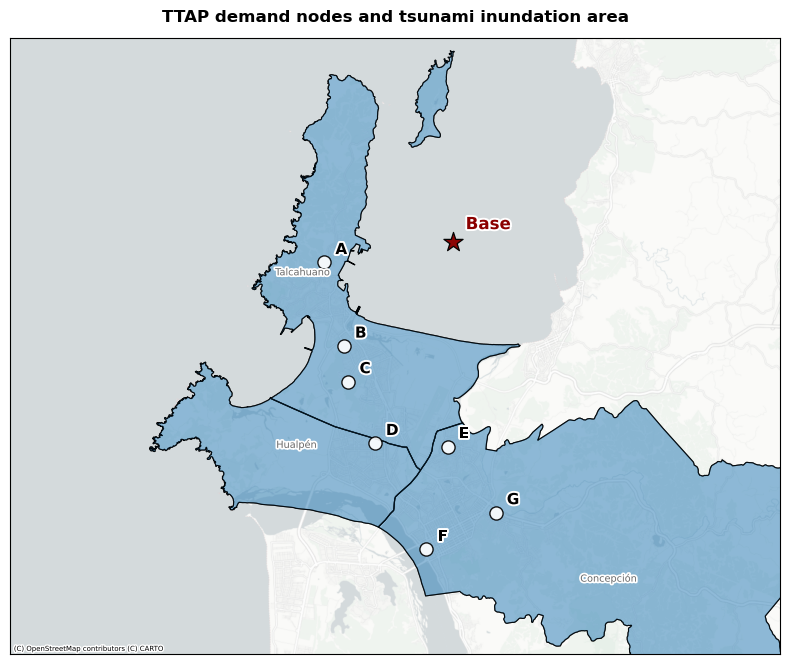

In [11]:
import os
import unicodedata

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from shapely.geometry import Point
import contextily as ctx

# ============================================================
# Parámetros del mapa
# ============================================================

MAP_NAME = "ttap_gps_area_map_comunas"
MAP_ZOOM_BASE = 12
MAP_ZOOM_LABELS = 11
FIG_SIZE = (8, 8)
PADDING_FACTOR = 0.12

# Ruta al shapefile comprimido
COMUNAS_PATH = "data/limites_comunales/comunas_final.zip"

if "FIGURES_DIR" not in globals():
    FIGURES_DIR = "figures_ttap_GPS"

os.makedirs(FIGURES_DIR, exist_ok=True)

# Comunas a mostrar
AREA_COMUNAS = [
    "Talcahuano",
    "Concepción",
    "Hualpén",
    #"Penco",
    #"Tomé",
    #"San Pedro de la Paz",
    #"Chiguayante",
]

# ============================================================
# Datos GPS de nodos TTAP
# ============================================================

GPS_NODES_FULL = {
    "Base": (-36.69111351421891, -73.0478599920742),
    "A": (-36.70062541801277, -73.12141380985622), # Cancha Colegio Arturo Prat
    "B": (-36.738871104828384, -73.1102591903089), # Estacionamiento Hospital Higueras
    "C": (-36.75513285670206, -73.10765044444817), # Estadio Cap Huachipato
    "D": (-36.78339332263817, -73.09259088926588), # Club Hípico
    "E": (-36.784954466865976, -73.05085478019805), # Colegio Kingston College
    "F": (-36.83173804040988, -73.06322287960043), # Parque Bicentenario
    "G": (-36.81499794336835, -73.02359653839595), # Estadio Ester Roa
}

ACTIVE_NODE_NAMES = ["Base", "A", "B", "C", "D", "E", "F", "G"]

# ============================================================
# Funciones auxiliares
# ============================================================

def normalize_text(value):
    """
    Normaliza texto para comparar nombres con o sin tilde.
    """

    if pd.isna(value):
        return ""

    value = str(value).strip().lower()

    value = "".join(
        c for c in unicodedata.normalize("NFD", value)
        if unicodedata.category(c) != "Mn"
    )

    return value


def read_comunas(path):
    """
    Lee el archivo de comunas.
    Intenta leer directamente el .zip y, si falla, usa zip://.
    """

    if not os.path.exists(path):
        raise FileNotFoundError(
            f"No existe el archivo de comunas en:\n{path}"
        )

    try:
        return gpd.read_file(path)
    except Exception:
        return gpd.read_file(f"zip://{path}")


def find_comuna_column(gdf):
    """
    Detecta la columna que contiene el nombre de la comuna.
    En tu archivo debería ser 'Comuna'.
    """

    candidate_columns = [
        "Comuna",
        "COMUNA",
        "comuna",
        "NOM_COMUNA",
        "nom_comuna",
        "NOMBRE_COM",
        "nombre_com",
        "NOMBRE",
        "nombre",
    ]

    for col in candidate_columns:
        if col in gdf.columns:
            return col

    raise ValueError(
        "No pude detectar la columna de nombre de comuna. "
        f"Columnas disponibles: {list(gdf.columns)}"
    )


# ============================================================
# Cargar límites comunales
# ============================================================

comunas = read_comunas(COMUNAS_PATH)

if comunas.crs is None:
    raise ValueError(
        "El archivo de comunas no tiene CRS definido. "
        "Debes asignar el CRS correcto antes de graficar."
    )

comuna_col = find_comuna_column(comunas)

comunas["_comuna_norm"] = comunas[comuna_col].apply(normalize_text)

area_comunas_norm = [
    normalize_text(name)
    for name in AREA_COMUNAS
]

comunas_area = comunas[
    comunas["_comuna_norm"].isin(area_comunas_norm)
].copy()

if comunas_area.empty:
    raise ValueError(
        "No se encontraron las comunas indicadas. "
        "Revisa AREA_COMUNAS y la columna de nombres."
    )

print("CRS comunas:", comunas.crs)
print("Columna usada para comuna:", comuna_col)
print("Comunas encontradas:")
display(comunas_area[[comuna_col]])

# ============================================================
# Crear GeoDataFrame de nodos TTAP
# ============================================================

node_rows = []

for name in ACTIVE_NODE_NAMES:
    lat, lon = GPS_NODES_FULL[name]

    node_rows.append({
        "name": name,
        "lat": lat,
        "lon": lon,
        "type": "Base" if name == "Base" else "Demand node",
        "geometry": Point(lon, lat),
    })

gdf_nodes = gpd.GeoDataFrame(
    node_rows,
    crs="EPSG:4326"
)

# ============================================================
# Reproyección a Web Mercator
# ============================================================
# Contextily usa mapas base en EPSG:3857.
# Por eso dejamos comunas y nodos en el mismo CRS.

comunas_3857 = comunas_area.to_crs(epsg=3857)
nodes_3857 = gdf_nodes.to_crs(epsg=3857)

# ============================================================
# Figura
# ============================================================

fig, ax = plt.subplots(figsize=FIG_SIZE)

# ============================================================
# Extensión del mapa
# ============================================================

# límites basados en los nodos, no en toda la geometría comunal
xmin, ymin, xmax, ymax = nodes_3857.total_bounds

# padding en metros (ajústalo a gusto)
padding_x = 3500
padding_y = 3500

ax.set_xlim(-8.151e6, -8.116e6)
ax.set_ylim(-4.420e6, -4.390e6)

# ============================================================
# Límites comunales, estilo GeoPandas gallery
# ============================================================
# Esto es lo que genera el efecto de "áreas azules delineadas".

comunas_3857.plot(
    ax=ax,
    color="tab:blue",
    alpha=0.32,
    edgecolor="black",
    linewidth=0.8,
    zorder=2,
    label="Communal boundaries"
)

# ============================================================
# Mapa base
# ============================================================
# Primero agregamos el fondo sin etiquetas.
# Luego agregamos solo las etiquetas encima, como sugiere la galería.

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.PositronNoLabels,
    zoom=MAP_ZOOM_BASE,
    reset_extent=False,
    attribution_size=5
)

# Volvemos a dibujar los bordes comunales encima del basemap,
# para asegurar que queden visibles.
comunas_3857.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.8,
    zorder=3
)

# Relleno comunal translúcido encima.
comunas_3857.plot(
    ax=ax,
    color="tab:blue",
    alpha=0.25,
    edgecolor="black",
    linewidth=0.8,
    zorder=4,
    label="Communal boundaries"
)

# ============================================================
# Etiquetas de comunas
# ============================================================

for _, row in comunas_3857.iterrows():
    point = row.geometry.representative_point()
    label = row[comuna_col]

    text = ax.annotate(
        label,
        xy=(point.x, point.y),
        ha="center",
        va="center",
        fontsize=7,
        color="dimgray",
        zorder=9
    )

    text.set_path_effects([
        path_effects.Stroke(linewidth=2.5, foreground="white"),
        path_effects.Normal()
    ])

# ============================================================
# Nodos TTAP
# ============================================================

nodes_3857[nodes_3857["type"] == "Demand node"].plot(
    ax=ax,
    markersize=90,
    marker="o",
    color="white",
    edgecolor="black",
    linewidth=1.0,
    alpha=0.90,
    zorder=8,
    label="Demand nodes"
)

nodes_3857[nodes_3857["type"] == "Base"].plot(
    ax=ax,
    markersize=210,
    marker="*",
    color="darkred",
    edgecolor="black",
    linewidth=0.9,
    alpha=0.98,
    zorder=8,
    label="Base"
)

# ============================================================
# Etiquetas de nodos
# ============================================================

label_offsets = {
    "Base": (9, 9),
    "A": (8, 6),
    "B": (8, 6),
    "C": (8, 6),
    "D": (8, 6),
    "E": (8, 6),
    "F": (8, 6),
    "G": (8, 6),
}

for _, row in nodes_3857.iterrows():

    dx, dy = label_offsets.get(row["name"], (8, 6))

    if row["name"] == "Base":
        label_color = "darkred"
        font_size = 12
    else:
        label_color = "black"
        font_size = 11

    text = ax.annotate(
        row["name"],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(dx, dy),
        textcoords="offset points",
        color=label_color,
        fontweight="bold",
        fontsize=font_size,
        zorder=8
    )

    text.set_path_effects([
        path_effects.Stroke(linewidth=2.8, foreground="white"),
        path_effects.Normal()
    ])

# ============================================================
# Estética final
# ============================================================

ax.set_title(
    "TTAP demand nodes and tsunami inundation area",
    fontsize=12,
    fontweight="bold",
    pad=12
)

# Quitar valores de los ejes
ax.set_xticks([])
ax.set_yticks([])

# Quitar marcas de los ejes
ax.tick_params(
    left=False,
    bottom=False,
    labelleft=False,
    labelbottom=False
)

plt.tight_layout()

# ============================================================
# Guardado
# ============================================================

png_path = os.path.join(FIGURES_DIR, f"{MAP_NAME}.png")
pdf_path = os.path.join(FIGURES_DIR, f"{MAP_NAME}.pdf")

fig.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    pdf_path,
    bbox_inches="tight",
    facecolor="white"
)

print(f"Map saved at: {png_path}")
print(f"Map saved at: {pdf_path}")

plt.show()

In [12]:
EVAC_POINTS_KMZ_PATH = "data/puntos_evacuacion/puntos_de_evacuacion.kmz"

evac_points_gdf = read_kmz_as_geodataframe(EVAC_POINTS_KMZ_PATH)

evac_points_gdf = evac_points_gdf[
    evac_points_gdf.geometry.notna() & ~evac_points_gdf.geometry.is_empty
].copy()

print("Puntos de evacuación cargados")
print("Shape:", evac_points_gdf.shape)
print("CRS:", evac_points_gdf.crs)
display(evac_points_gdf[["Name", "geometry"]].head())

Puntos de evacuación cargados
Shape: (29, 3)
CRS: EPSG:4326


,Name,geometry
0,PE1,POINT Z (-73.10099 -36.63965 0)
1,PE2,POINT Z (-73.0971 -36.64415 0)
2,PE3,POINT Z (-73.11717 -36.70923 0)
3,PE4,POINT Z (-73.11571 -36.71675 0)
4,PE5,POINT Z (-73.11459 -36.7172 0)


In [13]:
from shapely.geometry import Point

evac_points_gdf["geometry"] = evac_points_gdf["geometry"].apply(
    lambda geom: Point(geom.x, geom.y) if geom is not None else None
)

CRS comunas: EPSG:3857
Columna usada para comuna: Comuna
Comunas encontradas:


,Comuna
95,Concepción
175,Hualpén
176,Talcahuano


Map saved at: figures_ttap_GPS/GPS_7areas_6helos_30tasks/ttap_gps_area_map_comunas_tsunami_chart_ep.png
Map saved at: figures_ttap_GPS/GPS_7areas_6helos_30tasks/ttap_gps_area_map_comunas_tsunami_chart_ep.pdf


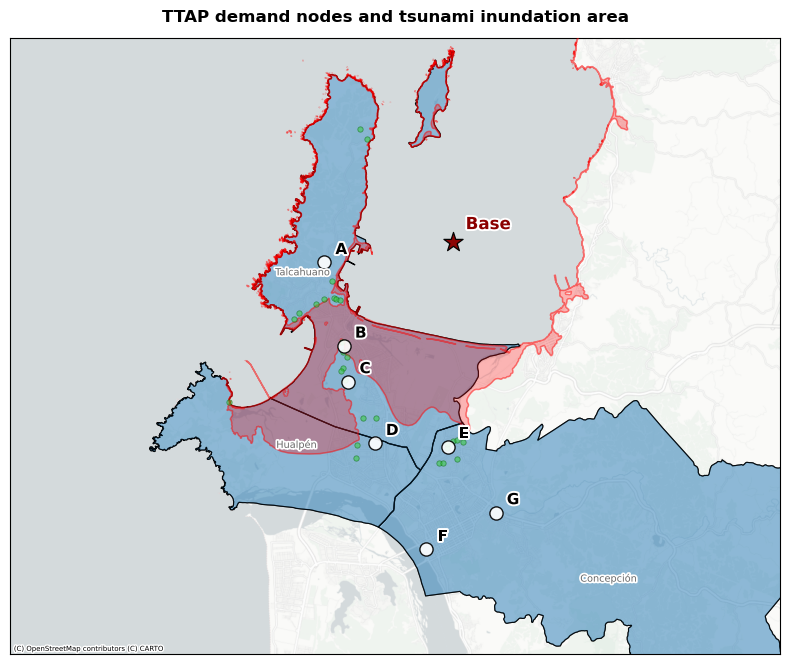

In [14]:
import os
import unicodedata

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from shapely.geometry import Point
import contextily as ctx

# ============================================================
# Parámetros del mapa
# ============================================================

MAP_NAME_TSUNAMI = "ttap_gps_area_map_comunas_tsunami_chart_ep"
MAP_ZOOM_BASE = 12
MAP_ZOOM_LABELS = 11
FIG_SIZE = (8, 8)
PADDING_FACTOR = 0.12

# Ruta al shapefile comprimido
COMUNAS_PATH = "data/limites_comunales/comunas_final.zip"

if "FIGURES_DIR" not in globals():
    FIGURES_DIR = "figures_ttap_GPS"

os.makedirs(FIGURES_DIR, exist_ok=True)

# Comunas a mostrar
AREA_COMUNAS = [
    "Talcahuano",
    "Concepción",
    "Hualpén",
    #"Penco",
    #"Tomé",
    #"San Pedro de la Paz",
    #"Chiguayante",
]

# ============================================================
# Datos GPS de nodos TTAP
# ============================================================

GPS_NODES_FULL = {
    "Base": (-36.69111351421891, -73.0478599920742),
    "A": (-36.70062541801277, -73.12141380985622), # Cancha Colegio Arturo Prat
    "B": (-36.738871104828384, -73.1102591903089), # Estacionamiento Hospital Higueras
    "C": (-36.75513285670206, -73.10765044444817), # Estadio Cap Huachipato
    "D": (-36.78339332263817, -73.09259088926588), # Club Hípico
    "E": (-36.784954466865976, -73.05085478019805), # Colegio Kingston College
    "F": (-36.83173804040988, -73.06322287960043), # Parque Bicentenario
    "G": (-36.81499794336835, -73.02359653839595), # Estadio Ester Roa
}

ACTIVE_NODE_NAMES = ["Base", "A", "B", "C", "D", "E", "F", "G"]

# ============================================================
# Funciones auxiliares
# ============================================================

def normalize_text(value):
    """
    Normaliza texto para comparar nombres con o sin tilde.
    """

    if pd.isna(value):
        return ""

    value = str(value).strip().lower()

    value = "".join(
        c for c in unicodedata.normalize("NFD", value)
        if unicodedata.category(c) != "Mn"
    )

    return value


def read_comunas(path):
    """
    Lee el archivo de comunas.
    Intenta leer directamente el .zip y, si falla, usa zip://.
    """

    if not os.path.exists(path):
        raise FileNotFoundError(
            f"No existe el archivo de comunas en:\n{path}"
        )

    try:
        return gpd.read_file(path)
    except Exception:
        return gpd.read_file(f"zip://{path}")


def find_comuna_column(gdf):
    """
    Detecta la columna que contiene el nombre de la comuna.
    En tu archivo debería ser 'Comuna'.
    """

    candidate_columns = [
        "Comuna",
        "COMUNA",
        "comuna",
        "NOM_COMUNA",
        "nom_comuna",
        "NOMBRE_COM",
        "nombre_com",
        "NOMBRE",
        "nombre",
    ]

    for col in candidate_columns:
        if col in gdf.columns:
            return col

    raise ValueError(
        "No pude detectar la columna de nombre de comuna. "
        f"Columnas disponibles: {list(gdf.columns)}"
    )


# ============================================================
# Cargar límites comunales
# ============================================================

comunas = read_comunas(COMUNAS_PATH)

if comunas.crs is None:
    raise ValueError(
        "El archivo de comunas no tiene CRS definido. "
        "Debes asignar el CRS correcto antes de graficar."
    )

comuna_col = find_comuna_column(comunas)

comunas["_comuna_norm"] = comunas[comuna_col].apply(normalize_text)

area_comunas_norm = [
    normalize_text(name)
    for name in AREA_COMUNAS
]

comunas_area = comunas[
    comunas["_comuna_norm"].isin(area_comunas_norm)
].copy()

if comunas_area.empty:
    raise ValueError(
        "No se encontraron las comunas indicadas. "
        "Revisa AREA_COMUNAS y la columna de nombres."
    )

print("CRS comunas:", comunas.crs)
print("Columna usada para comuna:", comuna_col)
print("Comunas encontradas:")
display(comunas_area[[comuna_col]])

# ============================================================
# Crear GeoDataFrame de nodos TTAP
# ============================================================

node_rows = []

for name in ACTIVE_NODE_NAMES:
    lat, lon = GPS_NODES_FULL[name]

    node_rows.append({
        "name": name,
        "lat": lat,
        "lon": lon,
        "type": "Base" if name == "Base" else "Demand node",
        "geometry": Point(lon, lat),
    })

gdf_nodes = gpd.GeoDataFrame(
    node_rows,
    crs="EPSG:4326"
)

# ============================================================
# Reproyección a Web Mercator
# ============================================================
# Contextily usa mapas base en EPSG:3857.
# Por eso dejamos comunas y nodos en el mismo CRS.

comunas_3857 = comunas_area.to_crs(epsg=3857)
nodes_3857 = gdf_nodes.to_crs(epsg=3857)
evac_points_3857 = evac_points_gdf.to_crs(epsg=3857)

# ============================================================
# Figura
# ============================================================

fig, ax = plt.subplots(figsize=FIG_SIZE)

# ============================================================
# Extensión del mapa
# ============================================================

# límites basados en los nodos, no en toda la geometría comunal
xmin, ymin, xmax, ymax = nodes_3857.total_bounds

# padding en metros (ajústalo a gusto)
padding_x = 3500
padding_y = 3500

ax.set_xlim(-8.151e6, -8.116e6)
ax.set_ylim(-4.420e6, -4.390e6)

# ============================================================
# Límites comunales, estilo GeoPandas gallery
# ============================================================
# Esto es lo que genera el efecto de "áreas azules delineadas".

comunas_3857.plot(
    ax=ax,
    color="tab:blue",
    alpha=0.32,
    edgecolor="black",
    linewidth=0.8,
    zorder=2,
    label="Communal boundaries"
)

# ============================================================
# Mapa base
# ============================================================
# Primero agregamos el fondo sin etiquetas.
# Luego agregamos solo las etiquetas encima, como sugiere la galería.

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.PositronNoLabels,
    zoom=MAP_ZOOM_BASE,
    reset_extent=False,
    attribution_size=5
)

# Volvemos a dibujar los bordes comunales encima del basemap,
# para asegurar que queden visibles.
comunas_3857.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.8,
    zorder=3
)

# Relleno comunal translúcido encima.
comunas_3857.plot(
    ax=ax,
    color="tab:blue",
    alpha=0.25,
    edgecolor="black",
    linewidth=0.8,
    zorder=4,
    label="Communal boundaries"
)

# ============================================================
# Carta de inundación por tsunami
# ============================================================

tsunami_area_3857.plot(
    ax=ax,
    color="red",
    alpha=0.28,
    edgecolor="red",
    linewidth=1.0,
    zorder=5,
    label="Tsunami inundation area"
)

# Borde más marcado de la zona de inundación
tsunami_area_3857.boundary.plot(
    ax=ax,
    color="red",
    linewidth=1.1,
    alpha=0.30,
    zorder=6
)

# ============================================================
# Puntos de evacuación
# ============================================================

evac_points_3857.plot(
    ax=ax,
    markersize=15,
    marker="o",
    color="limegreen",
    edgecolor="darkgreen",
    linewidth=0.6,
    alpha=0.50,
    zorder=7,
    label="Evacuation points"
)

# ============================================================
# Etiquetas de comunas
# ============================================================

for _, row in comunas_3857.iterrows():
    point = row.geometry.representative_point()
    label = row[comuna_col]

    text = ax.annotate(
        label,
        xy=(point.x, point.y),
        ha="center",
        va="center",
        fontsize=7,
        color="dimgray",
        zorder=9
    )

    text.set_path_effects([
        path_effects.Stroke(linewidth=2.5, foreground="white"),
        path_effects.Normal()
    ])

# ============================================================
# Nodos TTAP
# ============================================================

nodes_3857[nodes_3857["type"] == "Demand node"].plot(
    ax=ax,
    markersize=90,
    marker="o",
    color="white",
    edgecolor="black",
    linewidth=1.0,
    alpha=0.90,
    zorder=8,
    label="Demand nodes"
)

nodes_3857[nodes_3857["type"] == "Base"].plot(
    ax=ax,
    markersize=210,
    marker="*",
    color="darkred",
    edgecolor="black",
    linewidth=0.9,
    alpha=0.98,
    zorder=8,
    label="Base"
)

# ============================================================
# Etiquetas de nodos
# ============================================================

label_offsets = {
    "Base": (9, 9),
    "A": (8, 6),
    "B": (8, 6),
    "C": (8, 6),
    "D": (8, 6),
    "E": (8, 6),
    "F": (8, 6),
    "G": (8, 6),
}

for _, row in nodes_3857.iterrows():

    dx, dy = label_offsets.get(row["name"], (8, 6))

    if row["name"] == "Base":
        label_color = "darkred"
        font_size = 12
    else:
        label_color = "black"
        font_size = 11

    text = ax.annotate(
        row["name"],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(dx, dy),
        textcoords="offset points",
        color=label_color,
        fontweight="bold",
        fontsize=font_size,
        zorder=8
    )

    text.set_path_effects([
        path_effects.Stroke(linewidth=2.8, foreground="white"),
        path_effects.Normal()
    ])

# ============================================================
# Estética final
# ============================================================

ax.set_title(
    "TTAP demand nodes and tsunami inundation area",
    fontsize=12,
    fontweight="bold",
    pad=12
)

# Quitar valores de los ejes
ax.set_xticks([])
ax.set_yticks([])

# Quitar marcas de los ejes
ax.tick_params(
    left=False,
    bottom=False,
    labelleft=False,
    labelbottom=False
)

plt.tight_layout()

# ============================================================
# Guardado
# ============================================================

png_path = os.path.join(FIGURES_DIR, f"{MAP_NAME_TSUNAMI}.png")
pdf_path = os.path.join(FIGURES_DIR, f"{MAP_NAME_TSUNAMI}.pdf")

fig.savefig(
    png_path,
    dpi=1000,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    pdf_path,
    bbox_inches="tight",
    facecolor="white"
)

print(f"Map saved at: {png_path}")
print(f"Map saved at: {pdf_path}")

plt.show()

### 4. Método Greedy TTAP (Heurística):

In [15]:
class GreedyNode:
    def __init__(self, name, lat, lon):
        self.name = name
        self.lat = lat
        self.lon = lon
        self.tasks = []

    def add_task(self, task):
        self.tasks.append(task)

    def distance_to(self, other):
        """
        Distancia GPS aproximada entre nodos en kilómetros.
        """

        radius_earth_km = 6371.0088

        lat1_rad = math.radians(self.lat)
        lon1_rad = math.radians(self.lon)
        lat2_rad = math.radians(other.lat)
        lon2_rad = math.radians(other.lon)

        delta_lat = lat2_rad - lat1_rad
        delta_lon = lon2_rad - lon1_rad

        a = (
            math.sin(delta_lat / 2.0) ** 2
            + math.cos(lat1_rad)
            * math.cos(lat2_rad)
            * math.sin(delta_lon / 2.0) ** 2
        )

        c = 2.0 * math.asin(math.sqrt(a))

        return radius_earth_km * c


class GreedyTask:
    def __init__(
        self,
        task_id,
        visual_search,
        material_transport,
        medical_assistance,
        personnel_transfer,
        optimal_time,
        effective_time,
        ineffective_time,
    ):
        self.task_id = task_id
        self.visual_search = visual_search
        self.material_transport = material_transport
        self.medical_assistance = medical_assistance
        self.personnel_transfer = personnel_transfer
        self.optimal_time = optimal_time
        self.effective_time = effective_time
        self.ineffective_time = ineffective_time
        self.is_completed = False
        self.completion_time = None

    def calculate_satisfaction(self, t_finish):
        return satisfaction(
            t_finish,
            tasks[self.task_id]
        )


    def calculate_benefit(self, t_finish):
        return task_benefit(
            self.task_id,
            t_finish
        )


class GreedyHelicopter:
    def __init__(
        self,
        hid,
        visual_search_capability,
        load_capacity,
        medical_capacity,
        passenger_limit,
        speed_kmh,
        position,
    ):
        self.helicopter_id = hid
        self.visual_search_capability = visual_search_capability

        self.initial_load_capacity = load_capacity
        self.initial_medical_capacity = medical_capacity
        self.initial_passenger_limit = passenger_limit

        self.load_capacity = load_capacity
        self.medical_capacity = medical_capacity
        self.passenger_limit = passenger_limit

        self.speed_kmh = speed_kmh
        self.position = position
        self.available_time = 0.0
        self.blocked = False

    def can_complete_task(self, task):
        return (
            (not task.visual_search or self.visual_search_capability)
            and self.load_capacity >= task.material_transport
            and self.medical_capacity >= task.medical_assistance
            and self.passenger_limit >= task.personnel_transfer
        )

    def execute_task(self, task, t_finish):
        self.load_capacity -= task.material_transport
        self.medical_capacity -= task.medical_assistance
        self.passenger_limit -= task.personnel_transfer

        task.is_completed = True
        task.completion_time = t_finish

        return task.calculate_benefit(t_finish)

    def return_to_base_and_recover(self, base_node):
        tau = self.position.distance_to(base_node) / self.speed_kmh * 60.0
        duration = tau + RECOVERY_TIME
    
        k_now = int(round(self.available_time / TIME_UNIT))
        k_finish = k_now + ceil_steps(duration, TIME_UNIT)
        
        self.available_time = time_from_step(k_finish, TIME_UNIT)
        self.position = base_node
        
        self.load_capacity = self.initial_load_capacity
        self.medical_capacity = self.initial_medical_capacity
        self.passenger_limit = self.initial_passenger_limit
        
        return tau, RECOVERY_TIME


def initialize_greedy_graph():
    node_map = {
        node_name: GreedyNode(
            node_name,
            coord[0],
            coord[1],
        )
        for node_name, coord in nodes.items()
    }

    base = node_map["Base"]

    greedy_tasks = {}
    for i, t in tasks.items():
        greedy_tasks[i] = GreedyTask(
            task_id=i,
            visual_search=t["visual"],
            material_transport=t["load"],
            medical_assistance=t["med"],
            personnel_transfer=t["pers"],
            optimal_time=t["t_opt"],
            effective_time=t["t_eff"],
            ineffective_time=t["t_ineff"],
        )

    for task_id, node_name in task_to_node.items():
        node_map[node_name].add_task(greedy_tasks[task_id])

    greedy_helos = []
    for h, p in helicopters.items():
        greedy_helos.append(
            GreedyHelicopter(
                hid=helo_to_int(h),
                visual_search_capability=p["visual"],
                load_capacity=p["load"],
                medical_capacity=p["med"],
                passenger_limit=p["pers"],
                speed_kmh=p["speed"],
                position=base,
            )
        )

    return list(node_map.values()), greedy_helos, greedy_tasks


def next_available_helo(helicopters_list):
    active = [h for h in helicopters_list if not h.blocked]
    if not active:
        return None
    return min(active, key=lambda h: h.available_time)


def solve_greedy_ttap(T_max=TMAX, verbose=True):
    t0 = time.time()

    greedy_nodes, greedy_helos, greedy_tasks = initialize_greedy_graph()

    n_total_tasks = sum(len(n.tasks) for n in greedy_nodes)
    pending = n_total_tasks

    total_benefit = 0.0
    capacity_log = []
    completion_times = []
    individual_benefits = []

    while pending > 0:
        h = next_available_helo(greedy_helos)

        if h is None:
            break

        if h.available_time >= T_max:
            break

        t_now = h.available_time

        best_task = None
        best_node = None
        best_benefit = ZERO_BENEFIT_TOL
        best_tau = 0.0
        best_finish = 0.0

        for node in greedy_nodes:
            for task in node.tasks:
                if task.is_completed:
                    continue

                if not h.can_complete_task(task):
                    continue

                tau = h.position.distance_to(node) / h.speed_kmh * 60.0
                duration = tau + SERVICE_TIME
                k_now = int(round(t_now / TIME_UNIT))
                k_finish = k_now + ceil_steps(duration, TIME_UNIT)
                t_finish = time_from_step(k_finish, TIME_UNIT)

                if t_finish > T_max:
                    continue

                benefit = task.calculate_benefit(t_finish)

                if benefit <= ZERO_BENEFIT_TOL:
                    continue

                if benefit > best_benefit:
                    best_task = task
                    best_node = node
                    best_benefit = benefit
                    best_tau = tau
                    best_finish = t_finish

        if best_task is not None:
            h.position = best_node
            h.available_time = best_finish

            benefit = h.execute_task(best_task, best_finish)
            total_benefit += benefit
            pending -= 1

            completion_times.append(best_finish)
            individual_benefits.append(benefit)

            capacity_log.append({
                "Method": "Greedy",
                "Helo ID": h.helicopter_id,
                "Task ID": best_task.task_id,
                "Node": best_node.name,
                "Flight Time": best_tau,
                "Service Time": SERVICE_TIME,
                "Total Task Time": best_tau + SERVICE_TIME,
                "Completion Time": best_finish,
                "Benefit": benefit,
                "Remaining Load": h.load_capacity,
                "Remaining Medical": h.medical_capacity,
                "Remaining Personnel": h.passenger_limit,
                "Status": "Task Executed",
                "Priority Class": tasks[best_task.task_id]["priority_class"],
                "Task Weight": tasks[best_task.task_id]["weight"],
                "Temporal Satisfaction":best_task.calculate_satisfaction(best_finish),
            })

            if verbose:
                print(
                    f"H{h.helicopter_id} → T{best_task.task_id} "
                    f"fin={best_finish:.1f}' ΔB={benefit:.6f}"
                )

        else:
            base_node = greedy_nodes[0]

            if h.position != base_node:
                tau_return, t_recovery = h.return_to_base_and_recover(base_node)

                capacity_log.append({
                    "Method": "Greedy",
                    "Helo ID": h.helicopter_id,
                    "Task ID": "Idle",
                    "Node": "Base",
                    "Flight Time": tau_return,
                    "Service Time": t_recovery,
                    "Total Task Time": tau_return + t_recovery,
                    "Completion Time": h.available_time,
                    "Benefit": 0.0,
                    "Remaining Load": h.load_capacity,
                    "Remaining Medical": h.medical_capacity,
                    "Remaining Personnel": h.passenger_limit,
                    "Status": "Idle",
                })

                if verbose:
                    print(f"H{h.helicopter_id} → Base to recover")

            else:
                h.blocked = True

    runtime = time.time() - t0

    df_greedy = pd.DataFrame(capacity_log)

    completed_task_ids = sorted(
        df_greedy[df_greedy["Status"] == "Task Executed"]["Task ID"].astype(int).tolist()
    )

    uncompleted_task_ids = sorted(set(tasks.keys()) - set(completed_task_ids))

    summary = {
        "method": "Greedy",
        "benefit": total_benefit,
        "completed_tasks": len(completed_task_ids),
        "uncompleted_tasks": uncompleted_task_ids,
        "runtime_sec": runtime,
        "optimal": False,
        "solver_message": "Heuristic solution",
        "mip_gap": None,
    }

    if verbose:
        print("\n============================================================")
        print("GREEDY RESULTS")
        print("============================================================")
        print(f"Tareas completadas: {summary['completed_tasks']}/{len(tasks)}")
        print(f"Beneficio total   : {summary['benefit']:.6f}")
        print(f"Tareas no completadas: {summary['uncompleted_tasks']}")
        print(f"Runtime           : {summary['runtime_sec']:.6f} sec")

    return df_greedy, summary, completion_times, individual_benefits


df_greedy, greedy_summary, greedy_times, greedy_benefits = solve_greedy_ttap(
    T_max=TMAX,
    verbose=True
)

display(df_greedy)

H1 → T2 fin=9.0' ΔB=0.035398
H2 → T10 fin=9.0' ΔB=0.035398
H3 → T1 fin=8.0' ΔB=0.035398
H4 → T30 fin=9.0' ΔB=0.035398
H5 → T9 fin=8.0' ΔB=0.035398
H6 → T22 fin=11.0' ΔB=0.035398
H3 → T12 fin=16.0' ΔB=0.026549
H5 → T8 fin=16.0' ΔB=0.035398
H1 → Base to recover
H2 → Base to recover
H4 → Base to recover
H6 → T7 fin=21.0' ΔB=0.026549
H1 → T13 fin=23.0' ΔB=0.035398
H4 → T15 fin=23.0' ΔB=0.026549
H3 → Base to recover
H5 → T4 fin=24.0' ΔB=0.026549
H3 → T5 fin=30.0' ΔB=0.032460
H6 → T24 fin=30.0' ΔB=0.026549
H1 → Base to recover
H4 → Base to recover
H5 → Base to recover
H1 → T16 fin=37.0' ΔB=0.026529
H4 → T27 fin=37.0' ΔB=0.023238
H3 → T17 fin=37.0' ΔB=0.026529
H5 → T20 fin=40.0' ΔB=0.023391
H6 → Base to recover
H6 → T19 fin=46.0' ΔB=0.016715
H1 → Base to recover
H3 → Base to recover
H4 → Base to recover
H5 → T28 fin=48.0' ΔB=0.015042
H1 → T25 fin=53.0' ΔB=0.007111
H3 → T21 fin=52.0' ΔB=0.005218
H6 → Base to recover
H5 → Base to recover
H3 → Base to recover
H1 → Base to recover
H5 → T14 fin=64

,Method,Helo ID,Task ID,Node,Flight Time,Service Time,Total Task Time,Completion Time,Benefit,Remaining Load,Remaining Medical,Remaining Personnel,Status,Priority Class,Task Weight,Temporal Satisfaction
0,Greedy,1,2,A,2.097688,6.0,8.097688,9.0,0.035398,0,0,0,Task Executed,medical,2.0,1.000000
1,Greedy,2,10,A,2.097688,6.0,8.097688,9.0,0.035398,0,0,0,Task Executed,medical,2.0,1.000000
2,Greedy,3,1,A,1.897908,6.0,7.897908,8.0,0.035398,300,0,3,Task Executed,medical,2.0,1.000000
3,Greedy,4,30,E,2.982304,6.0,8.982304,9.0,0.035398,200,1,2,Task Executed,medical,2.0,1.000000
4,Greedy,5,9,A,1.992803,6.0,7.992803,8.0,0.035398,700,1,7,Task Executed,medical,2.0,1.000000
5,Greedy,6,22,F,4.708959,6.0,10.708959,11.0,0.035398,600,2,6,Task Executed,medical,2.0,1.000000
6,Greedy,3,12,B,1.247829,6.0,7.247829,16.0,0.026549,100,0,0,Task Executed,personnel,1.5,1.000000
7,Greedy,5,8,B,1.310221,6.0,7.310221,16.0,0.035398,550,0,6,Task Executed,medical,2.0,1.000000
8,Greedy,1,Idle,Base,2.097688,2.0,4.097688,14.0,0.000000,300,1,2,Idle,NaN,NaN,NaN
9,Greedy,2,Idle,Base,2.097688,2.0,4.097688,14.0,0.000000,300,1,2,Idle,NaN,NaN,NaN


### 5. Método Exacto TTAP (Solver:HIGHS - High-performance Software for Linear Optimization)

In [16]:
def ceil_steps(minutes, time_unit):
    return int(math.ceil((minutes - 1e-9) / time_unit))


def time_from_step(k, time_unit):
    return k * time_unit


def make_state(node, k, load, med, pers):
    return (node, int(k), int(load), int(med), int(pers))


def start_state(h):
    p = helicopters[h]
    return make_state("Base", 0, p["load"], p["med"], p["pers"])


def sink_state():
    return ("SINK", -1, 0, 0, 0)


def build_state_graph_for_helicopter(h, time_unit=TIME_UNIT):
    tmax_steps = int(round(TMAX / time_unit))

    s0 = start_state(h)
    sink = sink_state()

    states = set([s0])
    queue = deque([s0])
    arcs = []

    while queue:
        current_state = queue.popleft()

        node, k, load, med, pers = current_state
        current_time = time_from_step(k, time_unit)

        # -----------------------------
        # Arcos de tarea
        # -----------------------------
        for task_id in tasks:

            if not can_execute_task_by_resources(h, task_id, load, med, pers):
                continue

            task_node = task_to_node[task_id]

            flight = travel_time_minutes(h, node, task_node)
            duration = flight + SERVICE_TIME
            duration_steps = ceil_steps(duration, time_unit)

            k_new = k + duration_steps

            if k_new > tmax_steps:
                continue

            finish_time = time_from_step(k_new, time_unit)

            task = tasks[task_id]

            new_state = make_state(
                task_node,
                k_new,
                load - task["load"],
                med - task["med"],
                pers - task["pers"],
            )

            benefit = task_benefit(task_id, finish_time)

            # Evita crear arcos de tareas que ya no generan valor operacional.
            if benefit <= ZERO_BENEFIT_TOL:
                continue

            arcs.append({
                "h": h,
                "from": current_state,
                "to": new_state,
                "kind": "task",
                "task": task_id,
                "start_time": current_time,
                "finish_time": finish_time,
                "flight_time": flight,
                "service_time": SERVICE_TIME,
                "benefit": benefit,
                "satisfaction": satisfaction(finish_time,task),
                "priority_class": task["priority_class"],
                "task_weight": task["weight"],
            })

            if new_state not in states:
                states.add(new_state)
                queue.append(new_state)

        # -----------------------------
        # Arco de retorno a base
        # -----------------------------
        if node != "Base":
            flight = travel_time_minutes(h, node, "Base")
            duration = flight + RECOVERY_TIME
            duration_steps = ceil_steps(duration, time_unit)

            k_new = k + duration_steps

            if k_new <= tmax_steps:
                p = helicopters[h]

                new_state = make_state(
                    "Base",
                    k_new,
                    p["load"],
                    p["med"],
                    p["pers"],
                )

                arcs.append({
                    "h": h,
                    "from": current_state,
                    "to": new_state,
                    "kind": "return",
                    "task": None,
                    "start_time": current_time,
                    "finish_time": time_from_step(k_new, time_unit),
                    "flight_time": flight,
                    "service_time": RECOVERY_TIME,
                    "benefit": 0.0,
                    "satisfaction": None,
                    "priority_class": None,
                    "task_weight": None,
                })

                if new_state not in states:
                    states.add(new_state)
                    queue.append(new_state)

    # -----------------------------
    # Arcos de término
    # -----------------------------
    states.add(sink)

    for s in list(states):
        if s == sink:
            continue

        node, k, load, med, pers = s

        if node != "Base":
            continue

        arcs.append({
            "h": h,
            "from": s,
            "to": sink,
            "kind": "end",
            "task": None,
            "start_time": time_from_step(k, time_unit),
            "finish_time": time_from_step(k, time_unit),
            "flight_time": 0.0,
            "service_time": 0.0,
            "benefit": 0.0,
            "satisfaction": None,
            "priority_class": None,
            "task_weight": None,
        })

    return list(states), arcs


def build_full_exact_graph(time_unit=TIME_UNIT):
    states_by_h = {}
    arcs_by_h = {}
    all_arcs = []

    print("\nConstruyendo red de estados exacta...\n")

    for h in helicopters:
        states, arcs = build_state_graph_for_helicopter(h, time_unit)

        states_by_h[h] = states
        arcs_by_h[h] = arcs
        all_arcs.extend(arcs)

        print(f"{h}: {len(states):,} estados | {len(arcs):,} arcos")

    print(f"\nTotal arcos/variables binarias: {len(all_arcs):,}")

    return states_by_h, arcs_by_h, all_arcs


def build_exact_milp_matrices(states_by_h, arcs_by_h, all_arcs):
    n_vars = len(all_arcs)

    c = np.array([-arc["benefit"] for arc in all_arcs], dtype=float)

    lb = np.zeros(n_vars)
    ub = np.ones(n_vars)
    integrality = np.ones(n_vars, dtype=int)

    row_idx = []
    col_idx = []
    vals = []

    rhs_lb = []
    rhs_ub = []

    current_row = 0

    arc_global_index = {}
    offset = 0

    for h in helicopters:
        for local_idx, arc in enumerate(arcs_by_h[h]):
            arc_global_index[(h, local_idx)] = offset + local_idx
        offset += len(arcs_by_h[h])

    # -----------------------------
    # Conservación de flujo
    # -----------------------------
    for h in helicopters:
        outgoing = defaultdict(list)
        incoming = defaultdict(list)

        for local_idx, arc in enumerate(arcs_by_h[h]):
            j = arc_global_index[(h, local_idx)]
            outgoing[arc["from"]].append(j)
            incoming[arc["to"]].append(j)

        s0 = start_state(h)
        sink = sink_state()

        for state in states_by_h[h]:
            for j in outgoing.get(state, []):
                row_idx.append(current_row)
                col_idx.append(j)
                vals.append(1.0)

            for j in incoming.get(state, []):
                row_idx.append(current_row)
                col_idx.append(j)
                vals.append(-1.0)

            if state == s0:
                rhs = 1.0
            elif state == sink:
                rhs = -1.0
            else:
                rhs = 0.0

            rhs_lb.append(rhs)
            rhs_ub.append(rhs)
            current_row += 1

    # -----------------------------
    # Cada tarea máximo una vez
    # -----------------------------
    for task_id in tasks:
        for j, arc in enumerate(all_arcs):
            if arc["kind"] == "task" and arc["task"] == task_id:
                row_idx.append(current_row)
                col_idx.append(j)
                vals.append(1.0)

        rhs_lb.append(-np.inf)
        rhs_ub.append(1.0)
        current_row += 1

    A = coo_matrix(
        (vals, (row_idx, col_idx)),
        shape=(current_row, n_vars)
    ).tocsr()

    constraints = LinearConstraint(
        A,
        np.array(rhs_lb, dtype=float),
        np.array(rhs_ub, dtype=float)
    )

    bounds = Bounds(lb, ub)

    return c, integrality, bounds, constraints, A


def solve_exact_ttap_v01(time_unit=TIME_UNIT, time_limit=180, mip_rel_gap=1e-6, verbose=True):
    t0 = time.time()

    states_by_h, arcs_by_h, all_arcs = build_full_exact_graph(time_unit)

    c, integrality, bounds, constraints, A = build_exact_milp_matrices(
        states_by_h,
        arcs_by_h,
        all_arcs
    )

    print("\nResolviendo MILP exacto...\n")
    print(f"Variables binarias : {len(all_arcs):,}")
    print(f"Restricciones      : {A.shape[0]:,}")
    print(f"No ceros matriz A  : {A.nnz:,}")
    print(f"Time limit         : {time_limit} segundos")
    print(f"MIP relative gap   : {mip_rel_gap}")

    result = milp(
        c=c,
        integrality=integrality,
        bounds=bounds,
        constraints=constraints,
        options={
            "time_limit": time_limit,
            "mip_rel_gap": mip_rel_gap,
            "disp": verbose,
        }
    )

    runtime = time.time() - t0

    if result.x is None:
        raise RuntimeError("El solver no encontró solución factible.")

    objective_value = -result.fun

    if result.success:
        mip_gap = 0.0
    else:
        mip_gap = getattr(result, "mip_gap", None)

    summary = {
        "method": "Exact",
        "benefit": objective_value,
        "completed_tasks": None,
        "uncompleted_tasks": None,
        "runtime_sec": runtime,
        "optimal": bool(result.success),
        "solver_message": result.message,
        "mip_gap": mip_gap,
        "variables": len(all_arcs),
        "constraints": A.shape[0],
        "nonzeros": A.nnz,
    }

    print("\n============================================================")
    print("EXACT RESULTS")
    print("============================================================")
    print(f"Solver status      : {result.message}")
    print(f"Beneficio total    : {objective_value:.6f}")
    print(f"Runtime            : {runtime:.6f} sec")
    print(f"Óptimo certificado : {result.success}")

    return result, all_arcs, states_by_h, arcs_by_h, summary


def decode_exact_solution(result, all_arcs):
    selected_indices = [
        j for j, value in enumerate(result.x)
        if value > 0.5
    ]

    selected_arcs = [all_arcs[j] for j in selected_indices]

    selected_by_h = defaultdict(list)

    for arc in selected_arcs:
        selected_by_h[arc["h"]].append(arc)

    rows = []

    for h in helicopters:
        out_arc = {
            arc["from"]: arc
            for arc in selected_by_h[h]
        }

        current = start_state(h)

        while True:
            arc = out_arc.get(current)

            if arc is None:
                break

            if arc["kind"] == "end":
                break

            if arc["kind"] == "task":
                task_id = arc["task"]
                next_state = arc["to"]

                rows.append({
                    "Method": "Exact-HiGHS",
                    "Helo ID": helo_to_int(h),
                    "Task ID": task_id,
                    "Node": task_to_node[task_id],
                    "Flight Time": arc["flight_time"],
                    "Service Time": arc["service_time"],
                    "Total Task Time": arc["flight_time"] + arc["service_time"],
                    "Completion Time": arc["finish_time"],
                    "Benefit": arc["benefit"],
                    "Remaining Load": next_state[2],
                    "Remaining Medical": next_state[3],
                    "Remaining Personnel": next_state[4],
                    "Status": "Task Executed",
                    "Priority Class": arc["priority_class"],
                    "Task Weight": arc["task_weight"],
                    "Temporal Satisfaction": arc["satisfaction"],
                })

            elif arc["kind"] == "return":
                next_state = arc["to"]

                rows.append({
                    "Method": "Exact-HiGHS",
                    "Helo ID": helo_to_int(h),
                    "Task ID": "Idle",
                    "Node": "Base",
                    "Flight Time": arc["flight_time"],
                    "Service Time": arc["service_time"],
                    "Total Task Time": arc["flight_time"] + arc["service_time"],
                    "Completion Time": arc["finish_time"],
                    "Benefit": 0.0,
                    "Remaining Load": next_state[2],
                    "Remaining Medical": next_state[3],
                    "Remaining Personnel": next_state[4],
                    "Status": "Idle",
                    "Priority Class": arc["priority_class"],
                    "Task Weight": arc["task_weight"],
                    "Temporal Satisfaction": arc["satisfaction"],
                })

            current = arc["to"]

    df = pd.DataFrame(rows)

    if not df.empty:
        df = df.sort_values(
            by=["Completion Time", "Helo ID"]
        ).reset_index(drop=True)

    return df


result_exact, all_arcs, states_by_h, arcs_by_h, exact_summary = solve_exact_ttap_v01(
    time_unit=TIME_UNIT,
    time_limit=180,
    mip_rel_gap=1e-6,
    verbose=True
)

df_exact = decode_exact_solution(result_exact, all_arcs)

decoded_greedy_benefit = df_greedy.loc[
    df_greedy["Status"] == "Task Executed",
    "Benefit"
].sum()

decoded_exact_benefit = df_exact.loc[
    df_exact["Status"] == "Task Executed",
    "Benefit"
].sum()

selected_task_benefit = sum(
    arc["benefit"] * result_exact.x[j]
    for j, arc in enumerate(all_arcs)
    if arc["kind"] == "task"
)

selected_non_task_benefit = sum(
    arc["benefit"] * result_exact.x[j]
    for j, arc in enumerate(all_arcs)
    if arc["kind"] != "task"
)

assert np.isclose(
    greedy_summary["benefit"],
    decoded_greedy_benefit,
    atol=1e-8
)

assert np.isclose(
    exact_summary["benefit"],
    decoded_exact_benefit,
    atol=1e-8
)

assert np.isclose(
    exact_summary["benefit"],
    selected_task_benefit,
    atol=1e-8
)

assert np.isclose(
    selected_non_task_benefit,
    0.0,
    atol=1e-12
)

exact_completed = sorted(
    df_exact[df_exact["Status"] == "Task Executed"]["Task ID"].astype(int).tolist()
)

exact_summary["completed_tasks"] = len(exact_completed)
exact_summary["uncompleted_tasks"] = sorted(set(tasks.keys()) - set(exact_completed))

display(df_exact)

print("\nTareas completadas Exact:", exact_summary["completed_tasks"], "/", len(tasks))
print("Tareas no completadas Exact:", exact_summary["uncompleted_tasks"])


Construyendo red de estados exacta...

H1: 204 estados | 427 arcos
H2: 44 estados | 79 arcos
H3: 1,835 estados | 6,863 arcos
H4: 289 estados | 549 arcos
H5: 11,372 estados | 79,451 arcos
H6: 2,125 estados | 8,773 arcos

Total arcos/variables binarias: 96,142

Resolviendo MILP exacto...

Variables binarias : 96,142
Restricciones      : 15,899
No ceros matriz A  : 272,563
Time limit         : 180 segundos
MIP relative gap   : 1e-06
Running HiGHS 1.2.2 [date: 2023-05-05, git hash: n/a]
Copyright (c) 2022 ERGO-Code under MIT licence terms

EXACT RESULTS
Solver status      : Optimization terminated successfully. (HiGHS Status 7: Optimal)
Beneficio total    : 0.648956
Runtime            : 60.868307 sec
Óptimo certificado : True
Presolving model
14772 rows, 95015 cols, 270309 nonzeros
13029 rows, 92085 cols, 272208 nonzeros

Solving MIP model with:
   13029 rows
   92085 cols (92085 binary, 0 integer, 0 implied int., 0 continuous)
   272208 nonzeros

        Nodes      |    B&B Tree     |   

,Method,Helo ID,Task ID,Node,Flight Time,Service Time,Total Task Time,Completion Time,Benefit,Remaining Load,Remaining Medical,Remaining Personnel,Status,Priority Class,Task Weight,Temporal Satisfaction
0,Exact-HiGHS,3,1,A,1.897908,6.0,7.897908,8.0,0.035398,300,0,3,Task Executed,medical,2.0,1.000000
1,Exact-HiGHS,4,10,A,1.897908,6.0,7.897908,8.0,0.035398,200,1,2,Task Executed,medical,2.0,1.000000
2,Exact-HiGHS,1,16,C,2.808084,6.0,8.808084,9.0,0.035398,150,0,1,Task Executed,medical,2.0,1.000000
3,Exact-HiGHS,2,2,A,2.097688,6.0,8.097688,9.0,0.035398,0,0,0,Task Executed,medical,2.0,1.000000
4,Exact-HiGHS,5,3,B,2.307008,6.0,8.307008,9.0,0.035398,800,0,8,Task Executed,medical,2.0,1.000000
5,Exact-HiGHS,6,30,E,3.131419,6.0,9.131419,10.0,0.035398,600,2,6,Task Executed,medical,2.0,1.000000
6,Exact-HiGHS,3,Idle,Base,1.897908,2.0,3.897908,12.0,0.000000,500,2,4,Idle,NaN,NaN,NaN
7,Exact-HiGHS,4,Idle,Base,1.897908,2.0,3.897908,12.0,0.000000,500,2,4,Idle,NaN,NaN,NaN
8,Exact-HiGHS,1,Idle,Base,2.808084,2.0,4.808084,14.0,0.000000,300,1,2,Idle,NaN,NaN,NaN
9,Exact-HiGHS,2,Idle,Base,2.097688,2.0,4.097688,14.0,0.000000,300,1,2,Idle,NaN,NaN,NaN



Tareas completadas Exact: 27 / 30
Tareas no completadas Exact: [11, 23, 29]


#### 5.1. Detalle de States y Arcs:

In [17]:
def states_to_dataframe(states_by_h, time_unit=TIME_UNIT):
    rows = []

    for h, states in states_by_h.items():
        for state in states:
            node, k, load, med, pers = state

            if node == "SINK":
                continue

            rows.append({
                "Helo": h,
                "Node": node,
                "Time Step": k,
                "Time": k * time_unit,
                "Remaining Load": load,
                "Remaining Medical": med,
                "Remaining Personnel": pers,
                "State": state,
            })

    return (
        pd.DataFrame(rows)
        .sort_values(
            ["Helo", "Time Step", "Node", "Remaining Load", "Remaining Medical", "Remaining Personnel"]
        )
        .reset_index(drop=True)
    )

In [18]:
def arcs_to_dataframe(arcs_by_h):
    rows = []

    for h, arcs in arcs_by_h.items():
        for arc_id, arc in enumerate(arcs):
            rows.append({
                "Helo": h,
                "Arc ID": arc_id,
                "Kind": arc["kind"],
                "Task": arc["task"],
                "From State": arc["from"],
                "To State": arc["to"],
                "Start Time": arc["start_time"],
                "Finish Time": arc["finish_time"],
                "Flight Time": arc["flight_time"],
                "Service Time": arc["service_time"],
                "Benefit": arc["benefit"],
            })

    return (
        pd.DataFrame(rows)
        .sort_values(["Helo", "Start Time", "Finish Time", "Kind", "Arc ID"])
        .reset_index(drop=True)
    )

##### States:

In [19]:
df_states_exact = states_to_dataframe(states_by_h)
display(df_states_exact[df_states_exact["Helo"] == "H6"].head(10))

,Helo,Node,Time Step,Time,Remaining Load,Remaining Medical,Remaining Personnel,State
13739,H6,Base,0,0.0,900,3,8,"(Base, 0, 900, 3, 8)"
13740,H6,A,8,8.0,600,2,6,"(A, 8, 600, 2, 6)"
13741,H6,B,9,9.0,500,3,5,"(B, 9, 500, 3, 5)"
13742,H6,B,9,9.0,700,3,5,"(B, 9, 700, 3, 5)"
13743,H6,C,9,9.0,500,3,5,"(C, 9, 500, 3, 5)"
13744,H6,D,10,10.0,500,3,5,"(D, 10, 500, 3, 5)"
13745,H6,D,10,10.0,700,3,5,"(D, 10, 700, 3, 5)"
13746,H6,E,10,10.0,500,3,5,"(E, 10, 500, 3, 5)"
13747,H6,E,10,10.0,600,2,6,"(E, 10, 600, 2, 6)"
13748,H6,E,10,10.0,700,3,5,"(E, 10, 700, 3, 5)"


In [20]:
len(df_states_exact[df_states_exact["Helo"] == "H2"])

43

##### Arcs:

In [21]:
df_arcs_exact = arcs_to_dataframe(arcs_by_h)
display(df_arcs_exact[df_arcs_exact["Helo"] == "H5"].head(5))

,Helo,Arc ID,Kind,Task,From State,To State,Start Time,Finish Time,Flight Time,Service Time,Benefit
7918,H5,79422,end,NaN,"(Base, 0, 900, 3, 8)","(SINK, -1, 0, 0, 0)",0.0,0.0,0.000000,0.0,0.000000
7919,H5,0,task,1.0,"(Base, 0, 900, 3, 8)","(A, 8, 700, 1, 7)",0.0,8.0,1.992803,6.0,0.035398
7920,H5,1,task,2.0,"(Base, 0, 900, 3, 8)","(A, 8, 600, 2, 6)",0.0,8.0,1.992803,6.0,0.035398
7921,H5,8,task,9.0,"(Base, 0, 900, 3, 8)","(A, 8, 700, 1, 7)",0.0,8.0,1.992803,6.0,0.035398
7922,H5,9,task,10.0,"(Base, 0, 900, 3, 8)","(A, 8, 600, 2, 6)",0.0,8.0,1.992803,6.0,0.035398


### 6. Resumen comparativo básico:

In [22]:
basic_comparison = pd.DataFrame([
    {
        "Method": "Greedy",
        "Accumulated Benefit": greedy_summary["benefit"],
        "Completed Tasks": greedy_summary["completed_tasks"],
        "Completion Rate": greedy_summary["completed_tasks"] / len(tasks),
        "Uncompleted Tasks": greedy_summary["uncompleted_tasks"],
        "Runtime sec": greedy_summary["runtime_sec"],
        "Optimal Certified": greedy_summary["optimal"],
        "MIP Gap": greedy_summary["mip_gap"],
    },
    {
        "Method": "Exact-HiGHS",
        "Accumulated Benefit": exact_summary["benefit"],
        "Completed Tasks": exact_summary["completed_tasks"],
        "Completion Rate": exact_summary["completed_tasks"] / len(tasks),
        "Uncompleted Tasks": exact_summary["uncompleted_tasks"],
        "Runtime sec": exact_summary["runtime_sec"],
        "Optimal Certified": exact_summary["optimal"],
        "MIP Gap": exact_summary["mip_gap"],
    }
])

display(basic_comparison)

benefit_gain = exact_summary["benefit"] - greedy_summary["benefit"]
relative_gap_greedy_to_exact = benefit_gain / exact_summary["benefit"]

print("============================================================")
print("COMPARACIÓN DE CALIDAD")
print("============================================================")
print(f"Beneficio Greedy      : {greedy_summary['benefit']:.6f}")
print(f"Beneficio Exact       : {exact_summary['benefit']:.6f}")
print(f"Mejora absoluta       : {benefit_gain:.6f}")
print(f"Brecha relativa Greedy respecto del exacto: {100 * relative_gap_greedy_to_exact:.2f}%")

,Method,Accumulated Benefit,Completed Tasks,Completion Rate,Uncompleted Tasks,Runtime sec,Optimal Certified,MIP Gap
0,Greedy,0.593077,26,0.866667,"[3, 11, 23, 29]",0.000770,False,NaN
1,Exact-HiGHS,0.648956,27,0.900000,"[11, 23, 29]",60.868307,True,0.0


COMPARACIÓN DE CALIDAD
Beneficio Greedy      : 0.593077
Beneficio Exact       : 0.648956
Mejora absoluta       : 0.055879
Brecha relativa Greedy respecto del exacto: 8.61%


### 7. Gantt Chart:

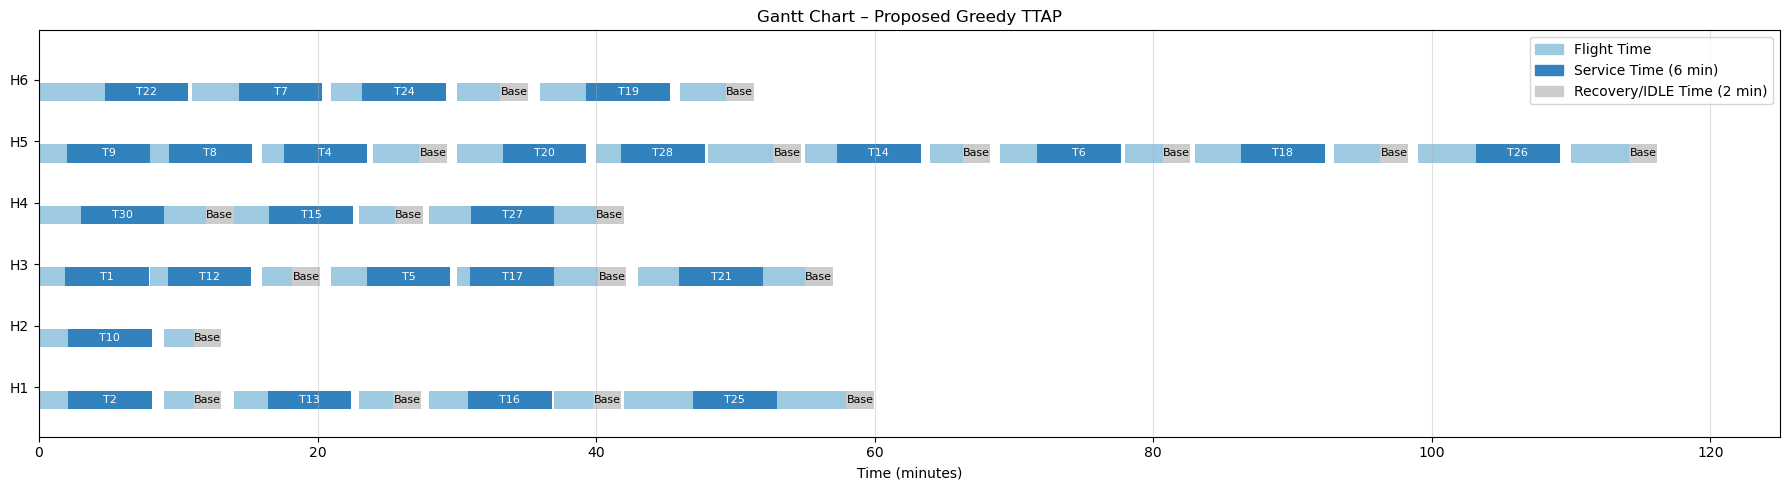

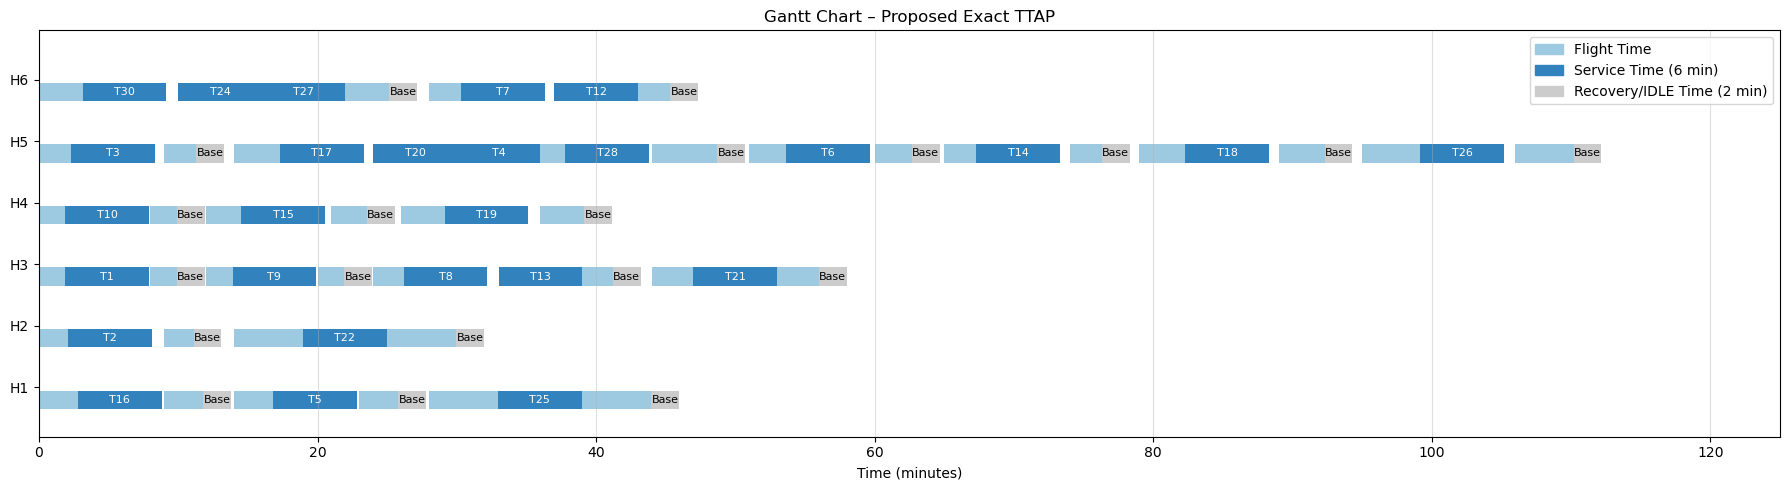

In [24]:
def plot_ttap_gantt_like_greedy(
    df_capacity,
    title="Gantt Chart – TTAP",
    fixed_service_time=6,
    show_benefit=False,
    xlim=(0, 160),
    save_path=None
):
    records = []
    prev_finish = {}

    df_plot = df_capacity.copy()
    df_plot["Helo ID"] = df_plot["Helo ID"].apply(helo_to_int)
    df_plot = df_plot.sort_values(by=["Completion Time", "Helo ID"]).reset_index(drop=True)

    for _, row in df_plot.iterrows():
        heli = int(row["Helo ID"])
        task = row["Task ID"]
        finish = float(row["Completion Time"])
        service_time = float(row["Service Time"])
        flight_time = float(row["Flight Time"])
        status = row["Status"]

        start = prev_finish.get(heli, 0.0)
        travel = flight_time
        actual_service = service_time
        prev_finish[heli] = finish

        benefit = None
        if "Benefit" in df_plot.columns and pd.notna(row["Benefit"]):
            benefit = float(row["Benefit"])

        records.append({
            "heli": heli,
            "task": task,
            "start": start,
            "travel": travel,
            "service": actual_service,
            "status": status,
            "benefit": benefit,
        })

    if not records:
        print("No hay datos para graficar.")
        return

    fig, ax = plt.subplots(figsize=(18, 5))

    colors = dict(
        travel="#9ecae1",
        service="#3182bd",
        idle="#cccccc"
    )

    for rec in records:
        y = rec["heli"]

        if rec["travel"] > 0:
            ax.broken_barh(
                [(rec["start"], rec["travel"])],
                (y - 0.35, 0.3),
                facecolors=colors["travel"]
            )

        service_start = rec["start"] + rec["travel"]

        ax.broken_barh(
            [(service_start, rec["service"])],
            (y - 0.35, 0.3),
            facecolors=colors["service"] if rec["status"] == "Task Executed" else colors["idle"]
        )

        if rec["status"] == "Task Executed":
            if show_benefit and rec["benefit"] is not None:
                label = f"T{rec['task']}\n{rec['benefit']:.3f}"
            else:
                label = f"T{rec['task']}"

            ax.text(
                service_start + rec["service"] / 2,
                y - 0.35 + 0.15,
                label,
                ha="center",
                va="center",
                color="white",
                fontsize=8
            )
        else:
            ax.text(
                service_start + rec["service"] / 2,
                y - 0.35 + 0.15,
                "Base",
                ha="center",
                va="center",
                color="black",
                fontsize=8
            )

    helos = sorted(set(r["heli"] for r in records))

    ax.set_xlabel("Time (minutes)")
    ax.set_yticks(helos)
    ax.set_yticklabels([f"H{i}" for i in helos])
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.4)
    ax.set_ylim(0.2, max(helos) + 0.8)

    if xlim is not None:
        ax.set_xlim(xlim)

    patches = [
        mpatches.Patch(color=colors["travel"], label="Flight Time"),
        mpatches.Patch(color=colors["service"], label=f"Service Time ({fixed_service_time} min)"),
        mpatches.Patch(color=colors["idle"], label="Recovery/IDLE Time (2 min)")
    ]

    ax.legend(handles=patches, loc="upper right")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=1000, bbox_inches="tight")

    plt.show()


plot_ttap_gantt_like_greedy(
    df_greedy,
    title="Gantt Chart – Proposed Greedy TTAP",
    show_benefit=False,
    xlim=(0, 125),
    save_path=os.path.join(FIGURES_DIR, "gantt_greedy_ttap.pdf")
)

plot_ttap_gantt_like_greedy(
    df_exact,
    title="Gantt Chart – Proposed Exact TTAP",
    show_benefit=False,
    xlim=(0, 125),
    save_path=os.path.join(FIGURES_DIR, "gantt_exact_ttap.pdf")
)

### 8. Beneficio acumulado:

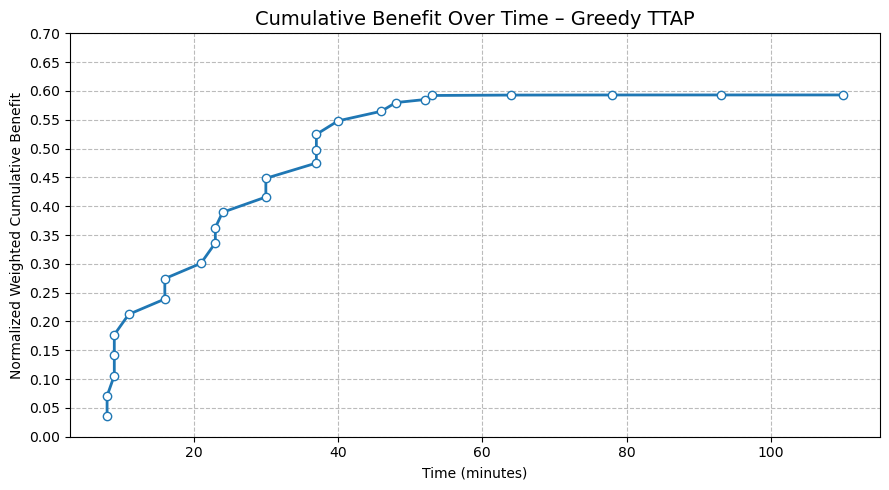

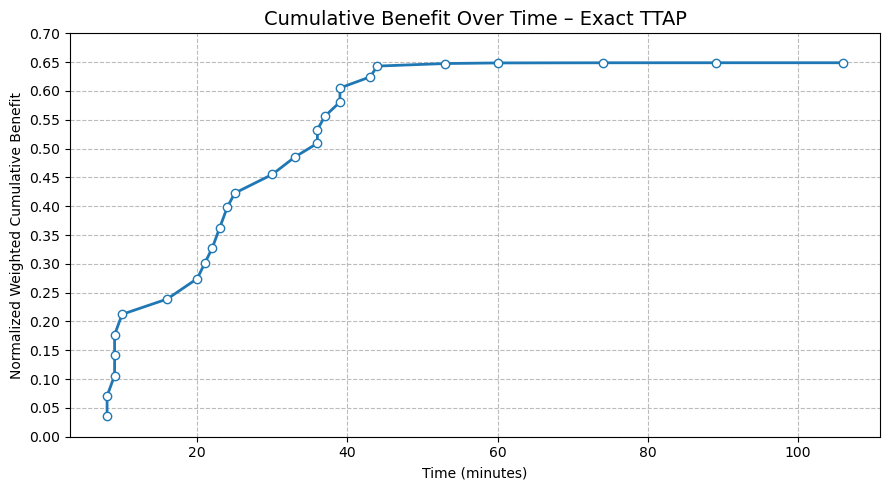

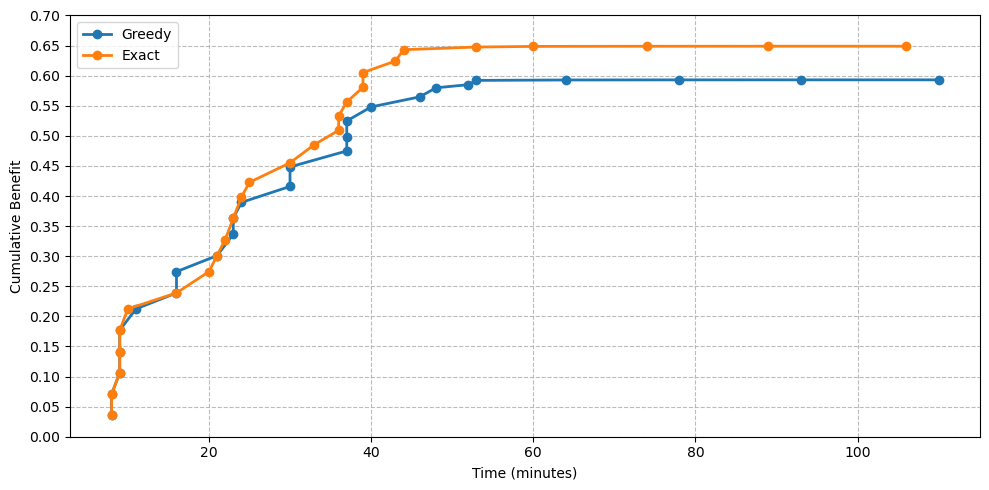

In [29]:
def plot_cumulative_benefit(df, title="Cumulative Benefit Over Time", save_path=None):
    task_df = df[df["Status"] == "Task Executed"].copy()

    if task_df.empty:
        print("No hay tareas ejecutadas.")
        return

    task_df = task_df.sort_values("Completion Time")
    task_df["Cumulative Benefit"] = task_df["Benefit"].cumsum()

    plt.figure(figsize=(9, 5))
    plt.plot(
        task_df["Completion Time"],
        task_df["Cumulative Benefit"],
        marker="o",
        markersize=6,
        markerfacecolor="white",
        markeredgecolor="#1f77b4",
        color="#1f77b4",
        linewidth=2
    )

    plt.xlabel("Time (minutes)")
    plt.ylabel("Normalized Weighted Cumulative Benefit")
    plt.title(title, fontsize=14)

    plt.ylim(BENEFIT_Y_MIN, 0.7)
    plt.yticks(
        np.arange(
            BENEFIT_Y_MIN,
            BENEFIT_Y_MAX + BENEFIT_Y_STEP,
            BENEFIT_Y_STEP
        )
    )
    
    plt.grid(True, axis="both", which="major", linestyle="--", linewidth=0.8, alpha=0.85)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=1000, bbox_inches="tight")
    plt.show()


def plot_cumulative_benefit_comparison(df_greedy, df_exact, save_path=None):
    def prepare(df, method):
        task_df = df[df["Status"] == "Task Executed"].copy()
        task_df = task_df.sort_values("Completion Time")
        task_df["Cumulative Benefit"] = task_df["Benefit"].cumsum()
        task_df["Method"] = method
        return task_df

    g = prepare(df_greedy, "Greedy")
    e = prepare(df_exact, "Exact")

    plt.figure(figsize=(10, 5))

    plt.plot(
        g["Completion Time"],
        g["Cumulative Benefit"],
        marker="o",
        linewidth=2,
        label="Greedy"
    )

    plt.plot(
        e["Completion Time"],
        e["Cumulative Benefit"],
        marker="o",
        linewidth=2,
        label="Exact"
    )

    plt.xlabel("Time (minutes)")
    plt.ylabel("Cumulative Benefit")
    #plt.title("Cumulative Benefit Comparison – Greedy vs Exact TTAP")

    plt.ylim(BENEFIT_Y_MIN, 0.7)
    plt.yticks(
        np.arange(
            BENEFIT_Y_MIN,
            BENEFIT_Y_MAX + BENEFIT_Y_STEP,
            BENEFIT_Y_STEP
        )
    )   
    
    plt.grid(True, axis="both", which="major", linestyle="--", linewidth=0.8, alpha=0.85)
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=2000, bbox_inches="tight")
    
    plt.show()


plot_cumulative_benefit(
    df_greedy,
    title="Cumulative Benefit Over Time – Greedy TTAP",
    save_path=os.path.join(FIGURES_DIR, "cumulative_benefit_greedy_ttap.pdf")
)

plot_cumulative_benefit(
    df_exact,
    title="Cumulative Benefit Over Time – Exact TTAP",
    save_path=os.path.join(FIGURES_DIR, "cumulative_benefit_exact_ttap.pdf")
)

plot_cumulative_benefit_comparison(
    df_greedy,
    df_exact,
    save_path=os.path.join(FIGURES_DIR, "cumulative_benefit_comparison_greedy_vs_exact.pdf")
)

### 9. Métricas comparativas:

In [26]:
def gini_coefficient(values):
    values = np.array(values, dtype=float)

    if len(values) == 0:
        return np.nan

    if np.all(values == 0):
        return 0.0

    values = np.sort(values)
    n = len(values)
    cumulative = np.cumsum(values)

    return (n + 1 - 2 * np.sum(cumulative) / cumulative[-1]) / n


def compute_ttap_metrics(df, method_name, runtime_sec=None, optimal=False, mip_gap=None, exact_benefit_reference=None):
    df = df.copy()

    df["Helo ID"] = df["Helo ID"].apply(helo_to_int)

    task_df = df[df["Status"] == "Task Executed"].copy()
    idle_df = df[df["Status"] != "Task Executed"].copy()

    total_tasks = len(tasks)
    
    accumulated_benefit = task_df["Benefit"].sum() if not task_df.empty else 0.0
    
    # Tareas físicamente ejecutadas,
    # aunque hayan llegado tarde y tengan beneficio cero.
    physical_completed_tasks = task_df["Task ID"].nunique()
    
    # Tareas con beneficio estrictamente positivo.
    positive_task_df = task_df[task_df["Temporal Satisfaction"] > 0.0].copy()
    positive_completed_tasks = positive_task_df["Task ID"].nunique()
    
    # Tareas operacionalmente relevantes.
    # Esto elimina tareas con beneficio positivo, pero casi nulo.
    relevant_task_df = task_df[task_df["Temporal Satisfaction"]>= EFFECTIVE_SATISFACTION_THRESHOLD].copy()
    relevant_completed_tasks = relevant_task_df["Task ID"].nunique()
    
    physical_completion_rate = physical_completed_tasks / total_tasks
    positive_completion_rate = positive_completed_tasks / total_tasks
    relevant_completion_rate = relevant_completed_tasks / total_tasks

    # En escenario estático, todas las tareas están disponibles desde t=0.
    # Por tanto, response time = completion time.
    avg_response_time = task_df["Completion Time"].mean() if not task_df.empty else np.nan
    max_response_time = task_df["Completion Time"].max() if not task_df.empty else np.nan

    avg_activity_duration = task_df["Total Task Time"].mean() if not task_df.empty else np.nan
    max_activity_duration = task_df["Total Task Time"].max() if not task_df.empty else np.nan

    makespan = df["Completion Time"].max() if not df.empty else 0.0

    total_task_flight_time = task_df["Flight Time"].sum() if not task_df.empty else 0.0
    total_return_flight_time = idle_df["Flight Time"].sum() if not idle_df.empty else 0.0
    total_flight_time = total_task_flight_time + total_return_flight_time

    total_task_service_time = task_df["Service Time"].sum() if not task_df.empty else 0.0
    total_recovery_time = idle_df["Service Time"].sum() if not idle_df.empty else 0.0

    # Utilización de recursos:
    # - productive utilization: vuelo a tarea + servicio de tarea
    # - active utilization: vuelo total + servicio de tarea
    #   recuperación se considera no productiva.
    total_available_time = makespan * len(helicopters) if makespan > 0 else np.nan

    productive_time = total_task_flight_time + total_task_service_time
    active_time = total_flight_time + total_task_service_time

    productive_utilization = productive_time / total_available_time if total_available_time else np.nan
    active_utilization = active_time / total_available_time if total_available_time else np.nan

    # Operational cost proxy:
    operational_cost_proxy = total_flight_time + total_recovery_time

    # Load balancing
    helo_ids = sorted(
        helo_to_int(h)
        for h in helicopters.keys()
    )

    tasks_by_helo = (
        task_df.groupby("Helo ID")["Task ID"]
        .count()
        .reindex(helo_ids, fill_value=0)
    )

    workload_by_helo = (
        df.groupby("Helo ID")["Total Task Time"]
        .sum()
        .reindex(helo_ids, fill_value=0.0)
    )

    task_count_std = tasks_by_helo.std()
    task_count_cv = tasks_by_helo.std() / tasks_by_helo.mean() if tasks_by_helo.mean() > 0 else np.nan
    task_count_gini = gini_coefficient(tasks_by_helo.values)

    workload_std = workload_by_helo.std()
    workload_cv = workload_by_helo.std() / workload_by_helo.mean() if workload_by_helo.mean() > 0 else np.nan
    workload_gini = gini_coefficient(workload_by_helo.values)

    if exact_benefit_reference is not None and exact_benefit_reference > 0:
        optimality_gap_vs_exact = (exact_benefit_reference - accumulated_benefit) / exact_benefit_reference
    else:
        optimality_gap_vs_exact = np.nan

    metrics = {
        "Method": method_name,

        # Solution quality
        "Accumulated Benefit": accumulated_benefit,
        "Optimality Gap vs Exact": optimality_gap_vs_exact,

        # Task completion
        "Physical Completed Tasks": physical_completed_tasks,
        "Physical Completion Rate": physical_completion_rate,
        "Positive Benefit Tasks": positive_completed_tasks,
        "Positive Benefit Completion Rate": positive_completion_rate,
        "Operationally Relevant Tasks": relevant_completed_tasks,
        "Operationally Relevant Completion Rate": relevant_completion_rate,

        # Response time
        "Average Response Time": avg_response_time,
        "Maximum Response Time": max_response_time,
        "Average Activity Duration": avg_activity_duration,
        "Maximum Activity Duration": max_activity_duration,

        # Resource utilization
        "Makespan": makespan,
        "Total Available Fleet Time": total_available_time,
        "Productive Time": productive_time,
        "Active Time": active_time,
        "Productive Utilization": productive_utilization,
        "Active Utilization": active_utilization,

        # Operational cost proxies
        "Total Task Flight Time": total_task_flight_time,
        "Total Return Flight Time": total_return_flight_time,
        "Total Flight Time": total_flight_time,
        "Total Recovery Time": total_recovery_time,
        "Operational Cost Proxy": operational_cost_proxy,

        # Load balancing
        "Task Count Std": task_count_std,
        "Task Count CV": task_count_cv,
        "Task Count Gini": task_count_gini,
        "Workload Std": workload_std,
        "Workload CV": workload_cv,
        "Workload Gini": workload_gini,

        # Computational efficiency
        "Runtime sec": runtime_sec,
        "Optimal Certified": optimal,
        "MIP Gap": mip_gap,
    }

    detail = {
        "tasks_by_helo": tasks_by_helo,
        "workload_by_helo": workload_by_helo,
    }

    return metrics, detail


exact_reference_benefit = exact_summary["benefit"]

greedy_metrics, greedy_metric_detail = compute_ttap_metrics(
    df_greedy,
    method_name="Greedy",
    runtime_sec=greedy_summary["runtime_sec"],
    optimal=False,
    mip_gap=None,
    exact_benefit_reference=exact_reference_benefit
)

exact_metrics, exact_metric_detail = compute_ttap_metrics(
    df_exact,
    method_name="Exact - HiGHS",
    runtime_sec=exact_summary["runtime_sec"],
    optimal=exact_summary["optimal"],
    mip_gap=exact_summary["mip_gap"],
    exact_benefit_reference=exact_reference_benefit
)

df_metrics = pd.DataFrame([greedy_metrics, exact_metrics])

display(df_metrics.T)

,0,1
Method,Greedy,Exact - HiGHS
Accumulated Benefit,0.593077,0.648956
Optimality Gap vs Exact,0.086106,-0.0
Physical Completed Tasks,26,27
Physical Completion Rate,0.866667,0.9
Positive Benefit Tasks,26,27
Positive Benefit Completion Rate,0.866667,0.9
Operationally Relevant Tasks,19,22
Operationally Relevant Completion Rate,0.633333,0.733333
Average Response Time,35.846154,34.185185


### 10. Tabla de balance por Helo:

In [27]:
def build_helo_balance_table(df, method_name):
    df = df.copy()
    df["Helo ID"] = df["Helo ID"].apply(helo_to_int)

    task_df = df[df["Status"] == "Task Executed"].copy()

    balance = []

    for h in [1, 2, 3, 4, 5, 6]:
        df_h = df[df["Helo ID"] == h]
        task_h = task_df[task_df["Helo ID"] == h]

        balance.append({
            "Method": method_name,
            "Helo ID": f"H{h}",
            "Tasks Executed": task_h["Task ID"].nunique(),
            "Benefit": task_h["Benefit"].sum(),
            "Flight Time": df_h["Flight Time"].sum(),
            "Task Service Time": task_h["Service Time"].sum(),
            "Recovery Time": df_h[df_h["Status"] != "Task Executed"]["Service Time"].sum(),
            "Workload Time": df_h["Total Task Time"].sum(),
            "Last Completion Time": df_h["Completion Time"].max() if not df_h.empty else 0.0,
        })

    return pd.DataFrame(balance)


df_balance_greedy = build_helo_balance_table(df_greedy, "Greedy")
df_balance_exact = build_helo_balance_table(df_exact, "Exact")

df_balance = pd.concat([df_balance_greedy, df_balance_exact], ignore_index=True)

display(df_balance)

,Method,Helo ID,Tasks Executed,Benefit,Flight Time,Task Service Time,Recovery Time,Workload Time,Last Completion Time
0,Greedy,H1,4,0.104437,24.582002,24.0,8.0,56.582002,60.0
1,Greedy,H2,1,0.035398,4.195375,6.0,2.0,12.195375,14.0
2,Greedy,H3,5,0.126154,17.969519,30.0,6.0,53.969519,57.0
3,Greedy,H4,3,0.085185,17.010511,18.0,6.0,41.010511,42.0
4,Greedy,H5,9,0.136693,42.889174,54.0,12.0,108.889174,117.0
5,Greedy,H6,4,0.105210,19.998161,24.0,4.0,47.998161,52.0
6,Exact,H1,3,0.095266,21.145935,18.0,6.0,45.145935,46.0
7,Exact,H2,2,0.059922,14.108974,12.0,4.0,30.108974,32.0
8,Exact,H3,5,0.129859,17.950541,30.0,8.0,55.950541,58.0
9,Exact,H4,3,0.085755,15.167432,18.0,6.0,39.167432,42.0


_____